In [1]:
# MIT License
#
#@title Copyright (c) 2026 CCAI Community Authors { display-mode: "form" }
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

# Statistical Downscaling of Climate Projections with Deep Learning

**Author:**
*   Jose González-Abad, Instituto de Física de Cantabria (IFCA), CSIC-Universidad de Cantabria, gonzabad@ifca.es

This tutorial is a hands-on introduction to **statistical downscaling**: the problem of
turning the coarse output of a Global Climate Model (GCM) into the high-resolution,
local information that people actually need to plan for climate change. Using a New Zealand
subset of the [CORDEX ML-Bench](https://doi.org/10.5281/zenodo.20985924) dataset, you will
train a convolutional neural network to downscale daily **precipitation**, learn how to
evaluate it properly and use it to generate and compare **future precipitation projections**
driven by different GCMs.

> **Prerequisites:** basic Python/NumPy/xarray and a first
> exposure to neural networks. No prior deep climate-science knowledge is required.


# Table of Contents

*   [Overview](#overview)
*   [Climate Impact](#climate-impact)
*   [Background & Prerequisites](#background-and-prereqs)
*   [Software Requirements](#software-requirements)
*   [Data Description](#data-description)
*   [Introduction: Why We Need Downscaling](#introduction)
*   [Objectives](#objectives)
*   [Loading the Data](#loading-the-data)
*   [Preparing the Data for Training](#preparing-the-data)
*   [Model Definition](#model-definition)
*   [Model Training](#model-training)
*   [Model Evaluation](#model-evaluation)
*   [GCM Projections](#gcm-projections)
*   [Conclusions](#conclusions)
*   [References](#references)

<a name="overview"></a>
# Overview

Global Climate Models (GCMs) are our main tool for simulating future climate, but they run
at a coarse spatial resolution (typically ~100-200 km) that cannot represent the local
features (mountains, coastlines and valleys) and processes (convective thunderstorms) that shape the climate people actually
experience. **Downscaling** bridges that gap. In this tutorial we focus on **(empirical)
statistical downscaling**, where we *learn* a relationship between large-scale atmospheric
conditions and a local surface variable, and then apply it to climate-model output.

**What you will do**

1.  See, directly from data, *why* a coarse model cannot distinguish the climate of two
    nearby but very different locations on New Zealand's South Island.
2.  Train a small convolutional neural network (**DeepESD**) to downscale daily
    precipitation from large-scale predictors.
3.  Evaluate it with the diagnostics used in the downscaling literature and discover why a
    single error number can be misleading, especially for **extremes**.
4.  Generate **future precipitation projections** driven by two different GCMs and interpret
    the precipitation change signal and its uncertainty.

The training and evaluation code is written as small, reusable functions, so a closing
**challenge** invites you to plug in your own model and re-use the whole pipeline.

**Expected learning outcomes.** By the end you will be able to explain what statistical
downscaling is and when it is useful, train and *properly* evaluate a deep-learning
downscaling model and critically interpret a downscaled climate projection.


<a name="climate-impact"></a>
# Climate Impact

Adapting to climate change happens **locally**. A water utility sizing a reservoir, a
farmer choosing a crop, an engineer designing a culvert or a city planning for floods all
need to know how the climate will change *at their location* and not as an average over a
100-200 km grid box.

This is exactly where coarse GCMs fall short. A single GCM grid cell can cover a mountain
range, a rain shadow and a coastline at once, blending climates that are, on the ground,
completely different. **Regionalized (high-resolution) climate projections** turn global
model output into the kilometre-scale information adaptation decisions are built on.

Machine-learning downscaling makes this practical at scale: once trained, a model can
downscale **many** GCMs and **many** future scenarios in seconds, where traditional
high-resolution climate simulations cost orders of magnitude more CPU-hours. This lets decision-makers
explore a fuller range of plausible futures, including for instance the **uncertainty** between
models, which is essential for robust planning.

### Pathway to impact

The intended impact of this workflow is to support **local climate-risk and adaptation
decisions** that depend on precipitation at kilometre scales (flood design, water allocation,
agriculture, infrastructure). Downscaling does not by itself reduce climate risk, it improves
the *inputs* to impact models and planning processes so that those decisions can reflect
orographic and coastal contrasts that a coarse GCM washes out.

### Pathway to deployment

In an operational setting the steps are typically:

1.  **Train** on observations or a trusted high-resolution reference (here we use RCM
    pseudo-reality for teaching).
2.  **Evaluate** not only mean error but extremes and wet-day behaviour.
3.  **Apply** the model to GCM large-scale predictors for historical and future scenarios,
    preferably across several GCMs.
4.  **Interpret** the climate-change signal with awareness of GCM bias and the stationarity
    assumption.
5.  **Handoff** maps and time series to impact models, engineers or planners, with clear
    documentation of uncertainty and known failure modes.

Before real-world use, this kind of product needs domain review, often bias adjustment of the
driving GCM and institutional governance. It should **not** be used alone as a flood-design
or insurance number without that validation chain.

As you work through the tutorial, keep these questions in mind (we will return to them):

> **Reflection.** Think of a decision in your own region that depends on local climate
> (water, agriculture, energy, infrastructure, health…). What spatial resolution would
> that decision need? What could go wrong if it were based only on a coarse GCM?


<a name="background-and-prereqs"></a>
# Background & Prerequisites

**Prerequisites.** Comfort with `Python` and `NumPy` (ideally also `xarray`), and a basic idea
of how a neural network is trained (layers, a loss function, gradient descent). Everything
climate-specific is explained as we go.

**A few key concepts**, in plain terms:

*   **GCM (Global Climate Model).** A physics-based simulation of the whole Earth's climate,
    integrated on a coarse three-dimensional grid (in this tutorial the large-scale fields are on a
    ~2°, roughly 200 km horizontal grid). It captures the *large-scale* circulation well but
    not local detail.
*   **RCM (Regional Climate Model).** A higher-resolution physical model run over a limited
    area and driven at its boundaries by a GCM. It resolves local features (here, ~10 km) but
    is computationally very expensive.
*   **Dynamical vs statistical downscaling.** Local detail can be added to a GCM either
    *dynamically* (by running an RCM which is physically detailed but costly) or *statistically* (by
    learning an empirical link from data which is cheap, and the focus of this tutorial).
*   **Predictors and predictand.** In statistical downscaling we use **predictors**
    (large-scale atmospheric variables such as winds, humidity, temperature and geopotential
    at several pressure levels) to predict a local surface **predictand** (here, daily
    precipitation). This is equivalent to the concept of input and target in the ML jargon.
*   **Perfect-prognosis statistical downscaling.** We learn the predictor-predictand link
    during a historical period when we have both, then feed a *climate model's* large-scale
    predictors into the learned model to obtain high-resolution output, including for the
    future (see the schematic in the Introduction).
*   **Climate change signal.** The difference between a future climate statistic and its
    historical value (e.g. the change in mean precipitation), which is usually what matters
    for adaptation.
*   **Stationarity assumption.** Statistical downscaling assumes the learned
    predictor-predictand relationship still holds in a future, warmer climate (a strong
    assumption we should keep in mind whenever we extrapolate).

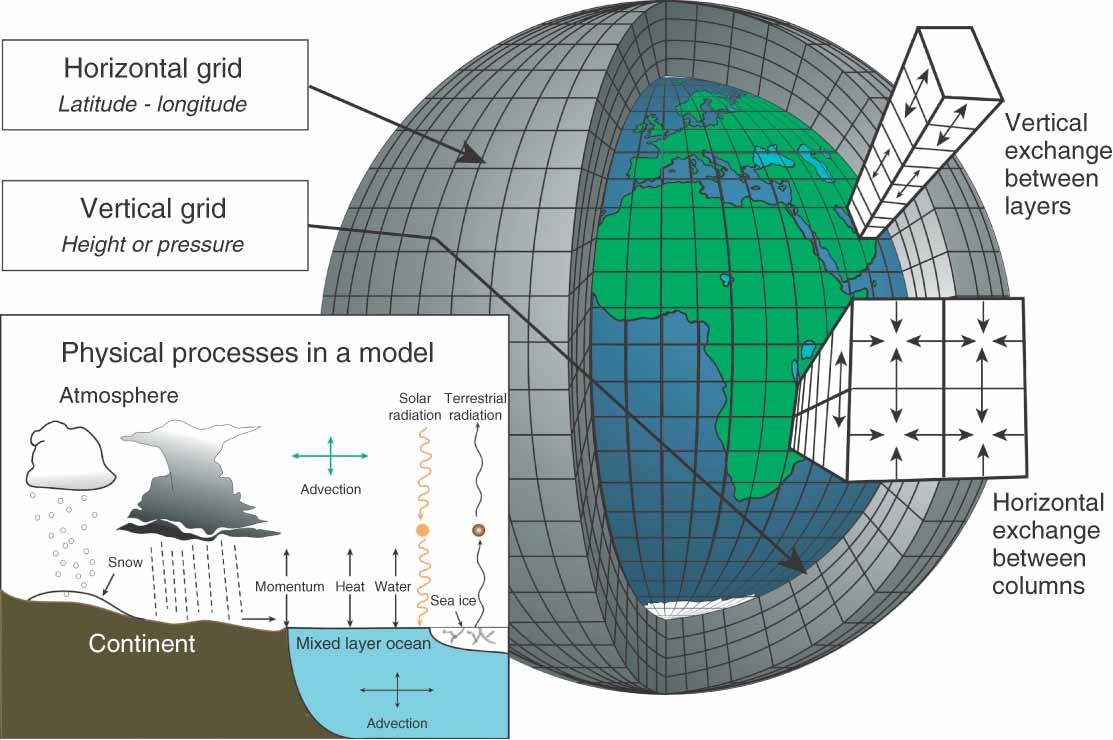

*Schematic of a GCM's discretisation. The model solves the equations of motion on a coarse
three-dimensional grid (horizontal ~100-200 km, plus vertical levels) and exchanges momentum,
heat and water between grid boxes. The grid spacing sets the smallest feature the model can
represent, which is why narrow mountain ranges and coastlines are blurred out. Source: Edwards, P. N. (2011). History of climate modeling. Wiley Interdisciplinary Reviews: Climate Change, 2(1), 128-139.*

**One important caveat: "pseudo-reality".** Real statistical downscaling links predictors to
*observations*. A benchmark, though, needs a known "truth" *everywhere* and *in the future*,
something observations can never provide. CORDEX ML-Bench therefore replaces observations
with the output of a high-resolution **RCM**, used as a proxy for reality (a
"**pseudo-reality**"). We adopt the same convention: wherever this tutorial says
"observations" or "the truth", it is really high-resolution RCM output. The upside is that we
can actually *check* our future projections against this pseudo-truth, impossible with real
observations.


<a name="software-requirements"></a>
# Software Requirements

This notebook uses Python ≥ 3.10 and the scientific-Python + `PyTorch` stack. The exact
versions are pinned in the companion **`requirements.txt`**. The main libraries are:

*   `numpy`, `pandas`: array and tabular data
*   `xarray`, `netcdf4`: labelled N-D climate data in NetCDF format
*   `matplotlib` (and optionally `cartopy`): plotting and maps
*   `torch`: the deep-learning framework
*   `requests`: download the tutorial data from Zenodo
*   `codecarbon`: track energy use and estimate CO₂ emissions during training

The next cell installs anything that is missing (it is safe to re-run, and a no-op if you
already have everything). On a fresh Google Colab runtime, installing `cartopy` may take a
minute but it is optional and the notebook produces the same maps (just without coastlines)
without it.


In [2]:
import importlib
import subprocess
import sys

def _ensure(packages):
    """pip-install any packages whose import name is not already available."""
    missing = []
    for import_name, pip_name in packages.items():
        if importlib.util.find_spec(import_name) is None:
            missing.append(pip_name)
    if missing:
        print("Installing:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=False)
    else:
        print("All required packages already available.")

# Basic libraries
_ensure({"numpy": "numpy",
         "pandas": "pandas",
         "xarray": "xarray",
         "netCDF4": "netcdf4",
         "matplotlib": "matplotlib",
         "torch": "torch",
         "requests": "requests",
         "codecarbon": "codecarbon"})

# Optional extra for nicer maps with coastlines
_ensure({"cartopy": "cartopy"})

All required packages already available.
All required packages already available.


We can now import all the libraries required to run this tutorial.

In [3]:
from pathlib import Path
import os
import zipfile

import numpy as np
import pandas as pd
import requests
import xarray as xr
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from codecarbon import EmissionsTracker

# Optional for nicer maps
try:
    import cartopy.crs as ccrs
    HAS_CARTOPY = True
except Exception:
    HAS_CARTOPY = False

# Reproducibility
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | device: {DEVICE} | cartopy: {HAS_CARTOPY}")

PyTorch 2.13.0+cpu | device: cpu | cartopy: True


## Configuration

Everything you might want to change lives in the single cell below: where the data is (local
paths or Zenodo download), the two locations we will compare, the time periods and the
model/training hyper-parameters.

> **Parameters to play with later** are flagged with `🔧` comments. For your first
> read-through, just run the cell as-is.


In [4]:
# Where is the data? Local paths are checked first; otherwise we download from Zenodo.
LOCAL_DATA_CANDIDATES = [Path("data-tutorial/NZ_domain"),
                         Path("NZ_domain")]

# Zenodo: tutorial subset (~3.3 GB). Full CORDEX-ML-Bench: https://doi.org/10.5281/zenodo.20985924
ZENODO_RECORD = "21425433"
ZENODO_ZIP_NAME = "NZ-subset.zip"
ZENODO_URL = (f"https://zenodo.org/records/{ZENODO_RECORD}/files/{ZENODO_ZIP_NAME}?download=1")

# Driving GCMs
GCM_TRAIN = "ACCESS-CM2"     # used for training + projection
GCM_TRANSFER = "EC-Earth3"   # a second, independent GCM used only for projection

# The two locations (NZ South Island)
# 🔧 Try other pairs of points once you understand the story.
POINT_WEST = {"name": "West Coast (Hokitika)", "lat": -42.72, "lon": 170.97}
POINT_EAST = {"name": "Southern Alps (mountain crest)", "lat": -42.95, "lon": 171.30}
POINTS = [POINT_WEST, POINT_EAST]

# Time periods
TRAIN_PERIOD = "1961-1980"      # model is trained here (present-day climate)
HIST_PERIOD = "1981-2000"       # independent historical test + present-day reference
FUTURE_PERIOD = "2080-2099"     # end-of-century projection
VAL_SPLIT_YEAR = 1977           # validation period for training

# Predictors
# 15 large-scale fields: u, v, q, t, z at 850/700/500 hPa.
# 🔧 You can drop levels/variables to see how skill changes
PRED_VARS = [f"{v}_{lev}" for v in ["u", "v", "q", "t", "z"] for lev in [850, 700, 500]]

# Model / training hyper-parameters
FILTERS_LAST_CONV = 1   # 🔧 channels in the last conv layer (model capacity)
BATCH_SIZE = 32         # 🔧
LEARNING_RATE = 1e-4    # 🔧
NUM_EPOCHS = 50         # 🔧 increase for longer training

# Where trained models are saved (created if needed)
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODELS_DIR / "deepesd_pr_nz.pt"

# CodeCarbon output
CODECARBON_DIR = Path("code_carbon")
CODECARBON_DIR.mkdir(exist_ok=True)

# Precipitation settings
WET_DAY_THRESHOLD = 1.0   # mm/day, threshold used to define a "wet day"
COARSEN_FACTOR = 16       # factor to average the 10 km field to a ~2deg "GCM-like" grid

<a name="data-description"></a>
# Data Description

We use a **New Zealand** subset of **[CORDEX ML-Bench](https://doi.org/10.5281/zenodo.20985924)**, a
community benchmark for machine-learning climate downscaling. The benchmark provides, for
several regions, the two ingredients statistical downscaling needs:

*   **Predictors**: large-scale atmospheric fields on a coarse **16 × 16** grid
    (~2°, roughly 200 km). More specifically, it provides zonal/meridional wind (`u`, `v`), specific humidity (`q`),
    temperature (`t`) and geopotential height (`z`), each at three pressure levels
    (850, 700, 500 hPa) reaching to **15 fields** in total, daily.
*   **Predictands**: the local surface variables on a high-resolution **128 × 128** grid
    (~10 km). More specifically daily maximum temperature (`tasmax`) and **precipitation (`pr`)**. *This
    tutorial focuses on precipitation* but the full benchmark also includes temperature.

The predictand comes from a regional climate model (RCM). As explained above we treat it as
our high-resolution "pseudo-reality". The data are stored as **NetCDF** files and read with
**`xarray`**, the standard tool for geoscientific data in Python.

**Periods and GCMs used in this tutorial:**

| Role | Period | Predictors | Target |
|------|--------|-----------|--------|
| Training | 1961–1980 | `ACCESS-CM2` (perfect) | `pr` |
| Test / present-day | 1981–2000 | `ACCESS-CM2` (perfect & imperfect) | `pr` |
| Future projection | 2080–2099 | `ACCESS-CM2` & `EC-Earth3` (imperfect/GCM) | `pr` |

*"Perfect" predictors are large-scale fields taken from the RCM itself (a best case),
"imperfect" predictors come from the driving **GCM**, the realistic situation when we
project the future. We will see why this distinction matters.*

The data for this tutorial are a reduced NZ subset on Zenodo
(**https://doi.org/10.5281/zenodo.21425433**). If you want to explore the full benchmark
later (all regions, both variables, additional experiments), see the complete CORDEX-ML-Bench
dataset: **https://doi.org/10.5281/zenodo.20985924** (CC-BY-4.0).


## Dataset datasheet (summary)

A compact datasheet for the data used in this notebook. For the full CORDEX-ML-Bench
documentation see the [full Zenodo record](https://doi.org/10.5281/zenodo.20985924) and the
[WCRP-CORDEX/ml-benchmark](https://github.com/WCRP-CORDEX/ml-benchmark) repository.

| Topic | Description |
|-------|-------------|
| **Motivation** | Provide open, standardised predictor/predictand pairs to train and evaluate ML downscaling over New Zealand. |
| **Composition** | Daily large-scale predictors (15 fields on 16×16) and high-resolution precipitation (`pr`, 128×128) from an RCM driven by ACCESS-CM2 and EC-Earth3. |
| **Collection** | Derived from CORDEX-CMIP6-style RCM/GCM simulations (CCAM-2203 RCM over NZ). |
| **Preprocessing for this tutorial** | Reduced NZ subset: precipitation only, ESD pseudo-reality training (1961–1980), historical (1981–2000) and end-century (2080–2099) tests. |
| **Distribution** | Tutorial subset on Zenodo (CC-BY-4.0): https://doi.org/10.5281/zenodo.21425433 (~3.3 GB). Full benchmark: https://doi.org/10.5281/zenodo.20985924. |
| **Limitations / gaps** | Pseudo-reality (RCM) instead of observations; one region; precipitation is skewed and hard to model; GCM predictors are biased relative to perfect predictors. |
| **Recommended use** | Research, teaching and method comparison for statistical downscaling (not a ready-to-use product for engineering design without further validation). |


## Getting the data

The cell below looks for a local `NZ_domain` folder. If it is missing, it **downloads** the
tutorial NZ subset from Zenodo (~3.3 GB, one-time), extracts it, and sets `DATA_ROOT`. After
it runs, all later cells use `DATA_ROOT` and a set of small path/loader helpers.

This subset contains only what the tutorial needs. The full CORDEX-ML-Bench dataset (all
regions and variables) is available separately at
https://doi.org/10.5281/zenodo.20985924 if you want to continue working beyond this notebook.

> **Note.** On Google Colab the download can take several minutes depending on bandwidth.
> Re-running the cell is safe: if the required files are already present, nothing is
> re-downloaded.


In [5]:
REQUIRED_RELATIVE_PATHS = [Path("train/ESD_pseudo_reality/predictors") / f"{GCM_TRAIN}_{TRAIN_PERIOD}.nc",
                           Path("train/ESD_pseudo_reality/target") / f"pr_tasmax_{GCM_TRAIN}_{TRAIN_PERIOD}.nc",
                           Path("test/historical/predictors/perfect") / f"{GCM_TRAIN}_{HIST_PERIOD}.nc",
                           Path("test/historical/predictors/imperfect") / f"{GCM_TRAIN}_{HIST_PERIOD}.nc",
                           Path("test/historical/predictors/imperfect") / f"{GCM_TRANSFER}_{HIST_PERIOD}.nc",
                           Path("test/historical/target") / f"pr_tasmax_{GCM_TRAIN}_{HIST_PERIOD}.nc",
                           Path("test/historical/target") / f"pr_tasmax_{GCM_TRANSFER}_{HIST_PERIOD}.nc",
                           Path("test/end_century/predictors/imperfect") / f"{GCM_TRAIN}_{FUTURE_PERIOD}.nc",
                           Path("test/end_century/predictors/imperfect") / f"{GCM_TRANSFER}_{FUTURE_PERIOD}.nc",
                           Path("test/end_century/target") / f"pr_tasmax_{GCM_TRAIN}_{FUTURE_PERIOD}.nc",
                           Path("test/end_century/target") / f"pr_tasmax_{GCM_TRANSFER}_{FUTURE_PERIOD}.nc"]

def _has_required_files(root: Path) -> bool:
    return all((root / rel).exists() for rel in REQUIRED_RELATIVE_PATHS)

def download_nz_domain(extract_to: Path = Path("."), zip_path=None) -> Path:
    """Download the tutorial NZ subset zip from Zenodo, extract it, and return NZ_domain."""
    extract_to = Path(extract_to)
    extract_to.mkdir(parents=True, exist_ok=True)
    zip_path = Path(zip_path) if zip_path is not None else extract_to / ZENODO_ZIP_NAME

    print(f"Downloading {ZENODO_ZIP_NAME} from Zenodo record {ZENODO_RECORD} ...")
    print(f"URL: {ZENODO_URL}")
    with requests.get(ZENODO_URL, stream=True, timeout=60) as response:
        response.raise_for_status()
        total = int(response.headers.get("Content-Length", 0))
        downloaded = 0
        with open(zip_path, "wb") as fh:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if not chunk:
                    continue
                fh.write(chunk)
                downloaded += len(chunk)
                if total:
                    pct = 100.0 * downloaded / total
                    print(f"\r  {downloaded / 1e9:.2f} / {total / 1e9:.2f} GB ({pct:5.1f}%)",
                          end="", flush=True)
        if total:
            print()

    print(f"Extracting to {extract_to.resolve()} ...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_to)
    zip_path.unlink(missing_ok=True)

    root = extract_to / "NZ_domain"
    if not root.exists():
        raise FileNotFoundError(
            f"Expected extracted folder '{root}' after download, but it was not found."
        )
    return root

def resolve_data_root():
    for candidate in LOCAL_DATA_CANDIDATES:
        if _has_required_files(candidate):
            print(f"Using local data at {candidate.resolve()}")
            return candidate

    # Common layout after a previous Zenodo extract in the working directory
    zenodo_root = Path("NZ_domain")
    if _has_required_files(zenodo_root):
        print(f"Using previously downloaded data at {zenodo_root.resolve()}")
        return zenodo_root

    root = download_nz_domain(extract_to=Path("."))
    if not _has_required_files(root):
        missing = [str(rel) for rel in REQUIRED_RELATIVE_PATHS if not (root / rel).exists()]
        raise FileNotFoundError(
            "Download finished but required files are missing:\n  - " + "\n  - ".join(missing)
        )
    print(f"DATA_ROOT ready at {root.resolve()}")
    return root

DATA_ROOT = resolve_data_root()
print("DATA_ROOT =", DATA_ROOT.resolve())
print("Required files present:", _has_required_files(DATA_ROOT))

URL: https://zenodo.org/records/21425433/files/NZ-subset.zip?download=1


  0.00 / 3.32 GB (  0.0%)

  0.00 / 3.32 GB (  0.1%)

  0.00 / 3.32 GB (  0.1%)

  0.00 / 3.32 GB (  0.1%)

...

  3.32 / 3.32 GB (100.0%)

  3.32 / 3.32 GB (100.0%)

  3.32 / 3.32 GB (100.0%)


Extracting to C:\Users\Miguel Cardoso\Desktop\personal\climatescience\downscaling-climate-projections ...


DATA_ROOT ready at C:\Users\Miguel Cardoso\Desktop\personal\climatescience\downscaling-climate-projections\NZ_domain
DATA_ROOT = C:\Users\Miguel Cardoso\Desktop\personal\climatescience\downscaling-climate-projections\NZ_domain
Required files present: True


The next two cells define a handful of small helper functions that we reuse throughout the
notebook. The first hides where each file lives on disk and loads the predictors and
precipitation for a given period and GCM, the second provides convenient utilities for
drawing maps and for sampling a field at a point. You do not need to memorise them, just run
the cells and use the helpers as they appear.


In [6]:
def _test_subdir(period):
    return {HIST_PERIOD: "historical", FUTURE_PERIOD: "end_century"}[period]

def predictors_path(period, kind="perfect", gcm=GCM_TRAIN):
    if period == TRAIN_PERIOD:
        return DATA_ROOT / "train/ESD_pseudo_reality/predictors" / f"{gcm}_{period}.nc"
    return DATA_ROOT / "test" / _test_subdir(period) / "predictors" / kind / f"{gcm}_{period}.nc"

def target_path(period, gcm=GCM_TRAIN):
    if period == TRAIN_PERIOD:
        return DATA_ROOT / "train/ESD_pseudo_reality/target" / f"pr_tasmax_{gcm}_{period}.nc"
    return DATA_ROOT / "test" / _test_subdir(period) / "target" / f"pr_tasmax_{gcm}_{period}.nc"

def load_predictors(period, kind="perfect", gcm=GCM_TRAIN):
    """Return an xarray.Dataset with the PRED_VARS large-scale fields (time, lat, lon)."""
    return xr.open_dataset(predictors_path(period, kind, gcm))[PRED_VARS]

def load_precip(period, gcm=GCM_TRAIN):
    """Return the high-resolution daily precipitation DataArray (time, lat, lon) in mm/day."""
    return xr.open_dataset(target_path(period, gcm))["pr"]

In [7]:
def make_map_axes(ncols=1, figsize=None):
    kw = {"subplot_kw": {"projection": ccrs.PlateCarree()}} if HAS_CARTOPY else {}
    fig, axes = plt.subplots(1, ncols, figsize=figsize or (5.2 * ncols, 4.8), **kw)
    axes = np.atleast_1d(axes)
    return fig, axes

def plot_field(ax, da, title="", cmap="viridis", vmin=None, vmax=None,
               points=None, cbar_label="", mark_color="red", title_fontsize=11):
    """Plot a 2-D (lat, lon) DataArray on `ax`, optionally marking POINTS."""
    is_geo = HAS_CARTOPY and hasattr(ax, "projection")
    geo = {"transform": ccrs.PlateCarree()} if is_geo else {}
    mesh = ax.pcolormesh(da["lon"], da["lat"], da, cmap=cmap, vmin=vmin, vmax=vmax,
                         shading="auto", **geo)
    lon_min, lon_max = float(da.lon.min()), float(da.lon.max())
    lat_min, lat_max = float(da.lat.min()), float(da.lat.max())
    if is_geo:
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        try:
            ax.coastlines(resolution="10m", linewidth=0.7, color="black")
        except Exception:
            pass
    else:
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, fontsize=title_fontsize)
    if points:
        for p in points:
            ax.scatter(p["lon"], p["lat"], s=45, color=mark_color, edgecolor="black",
                       zorder=5, **geo)
            ax.text(p["lon"] + 0.12, p["lat"], p["name"].split(" (")[0], fontsize=8,
                    zorder=6, **geo)
    plt.colorbar(mesh, ax=ax, shrink=0.75, pad=0.02, label=cbar_label)
    return mesh

def sample_point(da, point):
    """Nearest-grid-cell value(s) of `da` at a POINT dict."""
    return da.sel(lat=point["lat"], lon=point["lon"], method="nearest")

<a name="introduction"></a>
# Introduction: why we need downscaling

Imagine you advise two communities on New Zealand's South Island that are barely ~40 km apart
but live in very different rainfall regimes:

*   **The West Coast** (around Hokitika) sits on the windward coast of the Southern Alps.
    Moist westerly winds bring heavy rainfall here.
*   **The Southern Alps** (the mountain crest just inland) lie on the slopes immediately to
    the east, where the same westerlies are forced to rise and release  more moisture.
    This crest is one of the wettest spots in the domain, wetter still than the coast below.

Both communities want the same thing: *how will precipitation change here by the end of the
century?* This change (the future value minus the historical value) is the **climate change
signal**. Let's look at what a GCM can, and cannot, tell them.

First, the high-resolution "truth" (our RCM pseudo-reality): the mean daily precipitation over
the historical period.


C:\Users\Miguel Cardoso\Desktop\personal\climatescience\downscaling-climate-projections\.venv\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


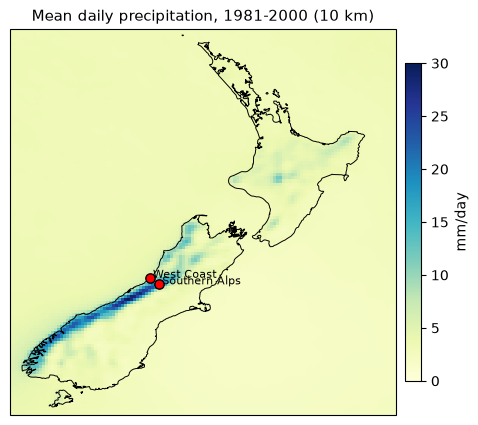

         West Coast (Hokitika):  6.89 mm/day
  Southern Alps (mountain crest): 22.92 mm/day


In [8]:
pr_hist = load_precip(HIST_PERIOD)
pr_hist_clim = pr_hist.mean("time").compute() # mean over the 20-year period

fig, axes = make_map_axes(ncols=1, figsize=(6, 5.5))
plot_field(axes[0], pr_hist_clim, title=f"Mean daily precipitation, {HIST_PERIOD} (10 km)",
           cmap="YlGnBu", vmin=0, vmax=30, points=POINTS, cbar_label="mm/day")
plt.show()

for p in POINTS:
    print(f"  {p['name']:>28}: {float(sample_point(pr_hist_clim, p)):5.2f} mm/day")

The contrast is striking: the Southern Alps crest receives more than three times the rainfall
of the West Coast just a few tens of kilometres away.

Now, **what does a coarse climate model see?** A GCM represents the surface on a grid of
roughly 2° (~200 km). The benchmark does not include the GCM's own surface precipitation (it
provides only the GCM's *large-scale* fields), so to mimic the coarse view we average
("upscale") the high-resolution field onto a much coarser grid. Keep in mind that a real GCM
*does* produce surface fields such as precipitation (`pr`) or temperature (`tas`) directly, here we simply emulate that coarse output from the high-resolution data we have. At ~2°
resolution the fine-scale orographic detail is smoothed away, and our two locations fall into
essentially the same coarse cell.


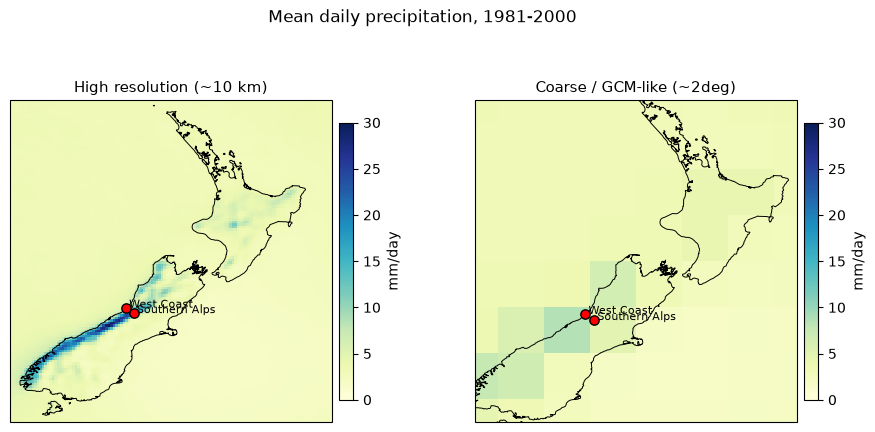

Mean precipitation at each location (mm/day):
                      location | high-res | coarse
         West Coast (Hokitika) |    6.89  |   8.52
  Southern Alps (mountain crest) |   22.92  |   4.78


In [9]:
def upscale_to_coarse(da, factor=COARSEN_FACTOR):
    """Average a (lat, lon) field onto a coarser grid to mimic a GCM's resolution."""
    return da.coarsen(lat=factor, lon=factor, boundary="trim").mean()

pr_hist_clim_coarse = upscale_to_coarse(pr_hist_clim)

fig, axes = make_map_axes(ncols=2, figsize=(11, 4.8))
plot_field(axes[0], pr_hist_clim, title="High resolution (~10 km)",
           cmap="YlGnBu", vmin=0, vmax=30, points=POINTS, cbar_label="mm/day")
plot_field(axes[1], pr_hist_clim_coarse, title="Coarse / GCM-like (~2deg)",
           cmap="YlGnBu", vmin=0, vmax=30, points=POINTS, cbar_label="mm/day")
plt.suptitle(f"Mean daily precipitation, {HIST_PERIOD}", y=1.02)
plt.show()

print("Mean precipitation at each location (mm/day):")
print(f"  {'location':>28} | high-res | coarse")
for p in POINTS:
    hi = float(sample_point(pr_hist_clim, p))
    lo = float(sample_point(pr_hist_clim_coarse, p))
    print(f"  {p['name']:>28} | {hi:7.2f}  | {lo:6.2f}")

At coarse resolution the two locations look almost indistinguishable and the coarse field
even assigns the Southern Alps crest a *lower* mean precipitation than the West Coast (about
4.8 vs 8.5 mm/day), the **opposite** of the high-resolution truth, where the crest is far
wetter. This is not a bug: at ~200 km the model simply cannot resolve the narrow mountain
barrier, so it blends the wet windward slope, the crest and the drier interior into a single
smoothed value. In other words, the coarse model literally cannot *see* the mountains that
separate our two points.

But the decision the communities care about is the **future change**. Let's compute the change
signal (future minus historical) at both resolutions.

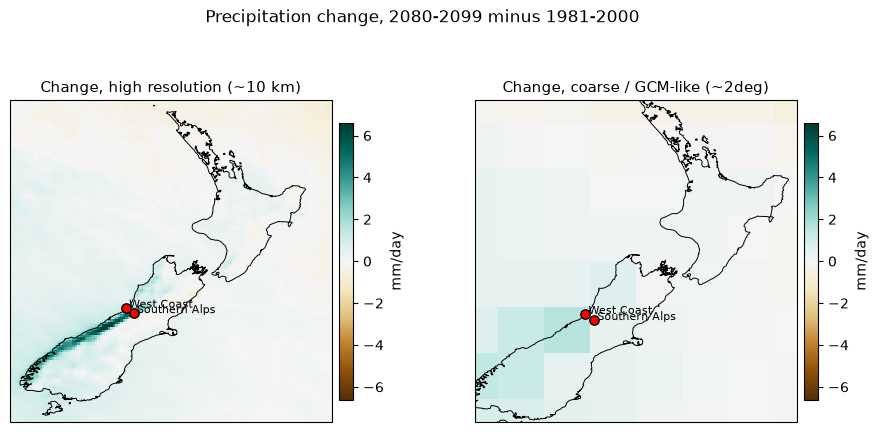

In [10]:
pr_future = load_precip(FUTURE_PERIOD) # ACCESS-CM2, 2080-2099
pr_future_clim = pr_future.mean("time").compute()

# Change signal = future mean - historical mean.
change_hi = pr_future_clim - pr_hist_clim
change_coarse = upscale_to_coarse(pr_future_clim) - pr_hist_clim_coarse

vlim = float(np.nanmax(np.abs(change_hi))) * 0.8
fig, axes = make_map_axes(ncols=2, figsize=(11, 4.8))
plot_field(axes[0], change_hi, title="Change, high resolution (~10 km)",
           cmap="BrBG", vmin=-vlim, vmax=vlim, points=POINTS, cbar_label="mm/day")
plot_field(axes[1], change_coarse, title="Change, coarse / GCM-like (~2deg)",
           cmap="BrBG", vmin=-vlim, vmax=vlim, points=POINTS, cbar_label="mm/day")
plt.suptitle(f"Precipitation change, {FUTURE_PERIOD} minus {HIST_PERIOD}", y=1.02)
plt.show()

Let’s also plot a bar chart showing the differences between the high- and coarse-resolution simulations for the points analyzed above.

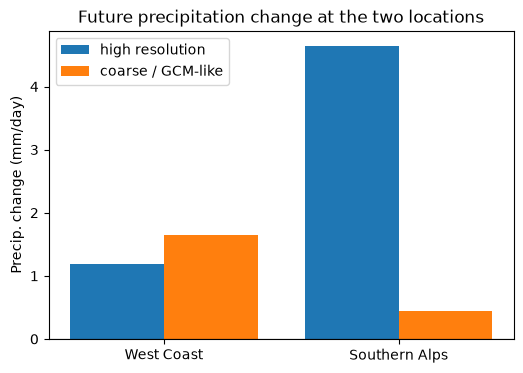

In [11]:
# Bar chart of the change at the two locations, at each resolution
labels = [p["name"].split(" (")[0] for p in POINTS]
chg_hi_pts = [float(sample_point(change_hi, p)) for p in POINTS]
chg_lo_pts = [float(sample_point(change_coarse, p)) for p in POINTS]
x = np.arange(len(POINTS))
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - 0.2, chg_hi_pts, width=0.4, label="high resolution")
ax.bar(x + 0.2, chg_lo_pts, width=0.4, label="coarse / GCM-like")
ax.axhline(0, color="k", linewidth=0.8)
ax.set_xticks(x, labels)
ax.set_ylabel("Precip. change (mm/day)")
ax.set_title("Future precipitation change at the two locations")
ax.legend()
plt.show()

> **Question 1.** Look at the coarse ("GCM-like") panel and the bars. Why do the two
> locations show a similar change, even though the high-resolution simulation says they
> change differently? What information has been lost?

**This is the core problem.** With only the coarse model, the two communities would plan for a
*similar* future, yet the high-resolution truth tells a more nuanced story. We need
**high-resolution projections of the future**.

But here is the catch: **we have no observations of the future.** We cannot simply look up what
precipitation *will* be. What we *can* do is learn, from the past, how local precipitation
relates to the large-scale atmospheric state, and then apply that relationship to a climate
model's projection of that large-scale state. That is **statistical downscaling**:

1.  In a **historical** period, learn a function mapping **large-scale predictors** (winds,
    humidity, temperature, geopotential) to **local precipitation**.
2.  Feed a **GCM's** large-scale predictors *for the future* into the learned function to
    obtain **high-resolution future precipitation**, including the local detail the GCM itself
    cannot resolve.

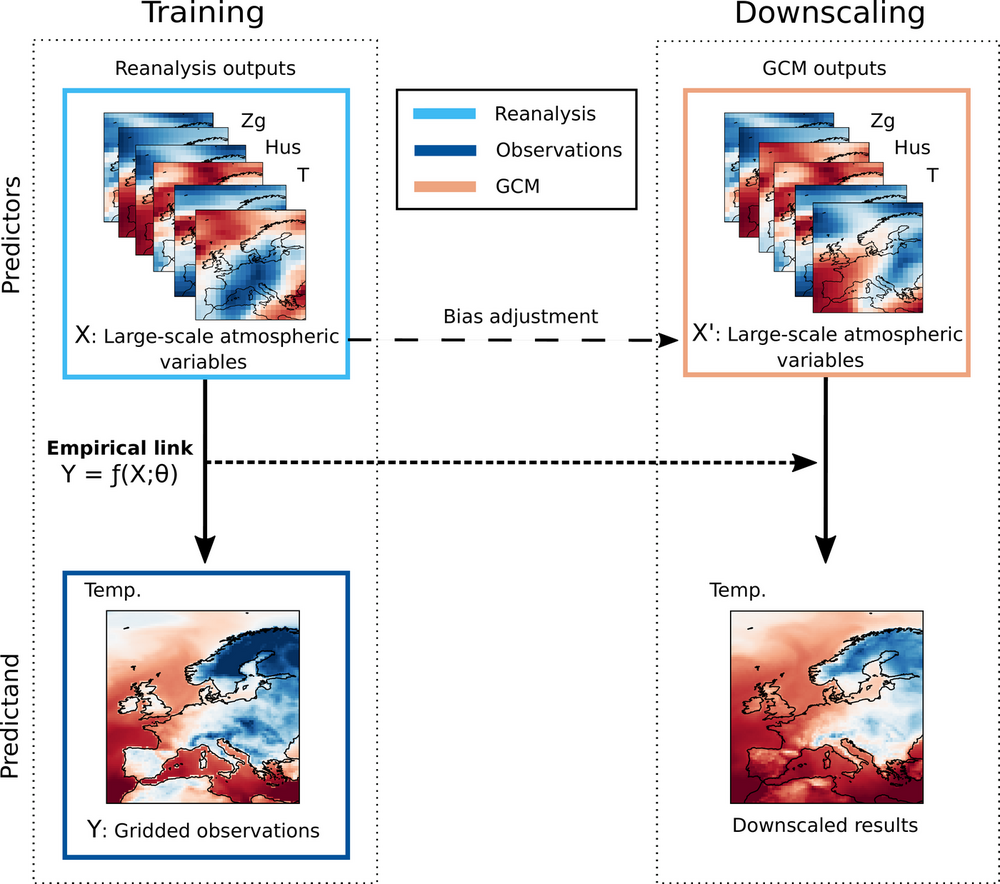

*Perfect-prognosis statistical downscaling. During **training** the empirical link
Y = f(X; θ) is fitted between large-scale predictors X (from a reanalysis or, in this
benchmark, the RCM's own upscaled large-scale fields) and the local predictand Y (gridded
observations, here our RCM "pseudo-reality"). For **downscaling**, the same link is applied to
a GCM's large-scale predictors X′ to produce the high-resolution result. Because the GCM and
the training predictors are not identical, a bias-adjustment step is sometimes inserted between
them (we will mention this later).*

**Why can we trust a GCM's large scale, but not its local detail (even in the future)?** It
comes down to what each scale *requires* in order to be represented faithfully. The large-scale
circulation we use as predictors (winds, humidity, temperature, geopotential) is governed by
processes that are *intrinsically* large: synoptic weather systems span thousands of
kilometres, so the coarse ~200 km grid of a GCM is already fine enough to characterise them
well, we do **not** need high resolution for these fields. Local surface precipitation, by
contrast, is shaped by features the coarse grid cannot resolve at all (a 10 km-wide mountain
range, a coastline, a valley). So we lean on the GCM for exactly what it does well (the large
scale) and let the downscaling model add the local detail it learned from high-resolution
data. In the rest of the notebook we build such a model and put it to work.


> **Answer.** The coarse grid averages the orography away: the West Coast and the
> Southern Alps crest fall within (essentially) the same ~2° cell, so both locations
> inherit the same cell-mean change. What has been lost is the fine-scale orographic
> structure — windward enhancement and rain shadow — that makes the two places respond
> *differently* to the same large-scale change.

<a name="objectives"></a>
# Objectives

From here on, we build and use a downscaling model, step by step:

1.  **Load the data**, the large-scale predictors and the precipitation predictand in the historical period.
2.  **Prepare the data** by defining training, validation and test periods and standardizing the
    inputs and shaping everything for PyTorch.
3.  **Define the model**, a compact convolutional network, *DeepESD*.
4.  **Train** it on the historical period and watch the loss curves.
5.  **Evaluate** it with a complete set of diagnostics, paying special
    attention to **extremes**.
6.  **Project the future** by downscaling two different GCMs and comparing their precipitation
    change signals.

The training and evaluation code is written as **reusable functions** so that, at the end,
you can swap in your own model and re-use the whole pipeline.

<a name="loading-the-data"></a>
# Loading the data

We now load the training data: the **predictors** and the **predictand**.

*   **Predictors (inputs).** The 15 large-scale fields `u, v, q, t, z` at 850/700/500 hPa.
    These describe the state of the atmosphere, how air is moving (`u`, `v`), how moist it
    is (`q`), how warm (`t`) and the pressure pattern (`z`). We use them because local
    precipitation is largely controlled by this large-scale circulation *and* because this
    is the part of a GCM we can trust for the future. They live on the coarse 16 × 16 grid.
*   **Predictand (target).** Daily precipitation `pr` in **mm/day**, on the 128 × 128
    (~10 km) grid. (The benchmark also provides daily maximum temperature `tasmax` but here we
    focus on precipitation, which is more challenging to downscale.)

Each file is a NetCDF dataset. `xarray` loads it as a `Dataset`/`DataArray` with named
dimensions (`time`, `lat`, `lon`) and coordinates, which makes subsetting straightforward.
The next cell plots **one training day** (all 15 coarse predictors and the matching
high-resolution precipitation) so you can see the full input/output pair.

In [12]:
predictors_train = load_predictors(TRAIN_PERIOD)   # Dataset: 15 vars, (time, lat, lon)
precip_train = load_precip(TRAIN_PERIOD)           # DataArray: pr (time, lat, lon)

print("Predictors:", dict(predictors_train.sizes))
print("Predictand 'pr':", dict(precip_train.sizes), "units:", precip_train.attrs.get("units"))

Predictors: {'time': 7300, 'lat': 16, 'lon': 16}
Predictand 'pr': {'time': 7300, 'lat': 128, 'lon': 128} units: None


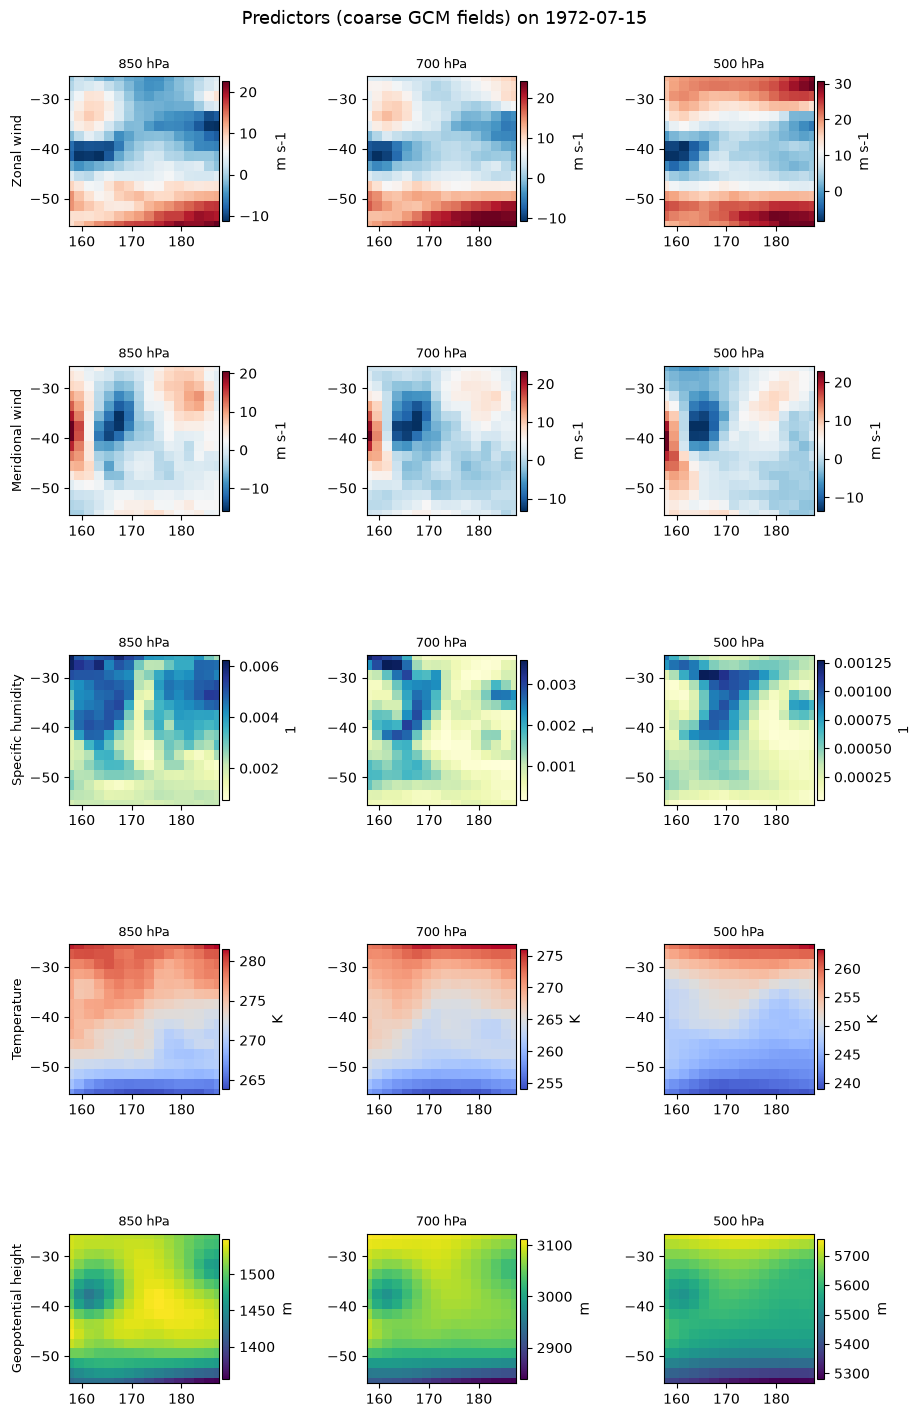

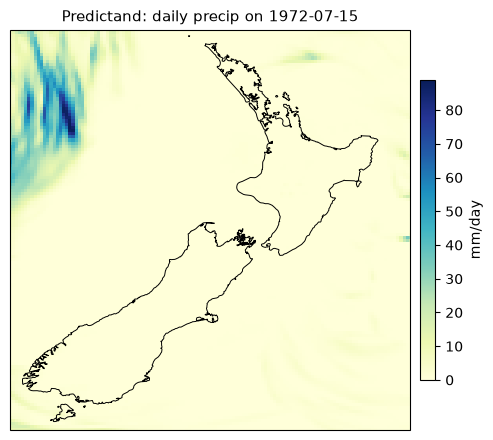

In [13]:
EXAMPLE_DAY = "1972-07-15"  # 🔧 try other dates within the training period

day_preds = predictors_train.sel(time=EXAMPLE_DAY, method="nearest")
day_pr = precip_train.sel(time=EXAMPLE_DAY, method="nearest")
example_date = str(np.datetime_as_string(day_preds.time.values, unit="D"))

PRED_CMAPS = {"u": "RdBu_r", "v": "RdBu_r", "q": "YlGnBu", "t": "coolwarm", "z": "viridis"}
_LONG = {"u": "Zonal wind", "v": "Meridional wind", "q": "Specific humidity",
         "t": "Temperature", "z": "Geopotential height"}
_VARS = ["u", "v", "q", "t", "z"]
_LEVS = [850, 700, 500]

fig, axes = plt.subplots(5, 3, figsize=(10, 16))
for row, v in enumerate(_VARS):
    for col, lev in enumerate(_LEVS):
        var = f"{v}_{lev}"
        ax  = axes[row, col]
        plot_field(ax, day_preds[var], title=f"{lev} hPa",
                   cmap=PRED_CMAPS[v],
                   cbar_label=day_preds[var].attrs.get("units", ""), title_fontsize=9)
        if col == 0:
            ax.set_ylabel(_LONG[v], fontsize=9, labelpad=4)
fig.suptitle(f"Predictors (coarse GCM fields) on {example_date}", fontsize=13)
fig.subplots_adjust(hspace=0.55, wspace=0.65, top=0.95)
plt.show()

subplot_kw = {"projection": ccrs.PlateCarree()} if HAS_CARTOPY else {}
fig, ax = plt.subplots(1, 1, figsize=(6.5, 5.2), subplot_kw=subplot_kw)
plot_field(ax, day_pr, title=f"Predictand: daily precip on {example_date}",
           cmap="YlGnBu", cbar_label="mm/day")
plt.show()

<a name="preparing-the-data"></a>
# Preparing the data for training

Three steps turn the raw NetCDF into something a neural network can learn from.

**1. Define the periods**

*   **Train** and **validation** both come from the 1961-1980 period (we train on the earlier
    years and validate on the later ones, so the validation set is genuinely unseen).
*   **Test** is the *independent* 1981-2000 period, never seen during training, which we use
    later to judge real skill.

**2. Standardize the predictors.** The 15 fields have wildly different units and ranges (m/s,
kg/kg, K, m). We rescale each to zero mean and unit variance, using statistics computed on the
**training years only** (so no information leaks from validation/test).

**3. Shape the arrays.** PyTorch works with tensors. The predictors become a 4-D tensor
`(days, 15, 16, 16)`, think of each day as a 15-channel "image", one channel per large-scale
field, on the 16 × 16 coarse grid. The precipitation target is flattened from the `(128, 128)`
map to a single vector of length `128 × 128 = 16384`, so each day becomes one input image
paired with one 16384-value output vector. The model therefore predicts every high-resolution
grid cell *simultaneously* from the coarse predictors, we simply reshape the output vector back
into a `(128, 128)` map whenever we want to plot it.


In [14]:
def standardization_stats(predictors_ds):
    """Per-field mean and std over time (computed on the TRAIN years only)."""
    return predictors_ds.mean("time"), predictors_ds.std("time")

def predictors_to_array(predictors_ds, mean, std):
    """Standardize and return a float32 array shaped (time, n_vars, lat, lon)."""
    ds_std = (predictors_ds - mean) / std
    arr = ds_std.to_array(dim="variable").transpose("time", "variable", "lat", "lon")
    return arr.values.astype("float32")

def precip_to_array(precip_da):
    """Flatten the spatial grid: (time, lat, lon) -> (time, lat*lon), float32."""
    n_time = precip_da.sizes["time"]
    return precip_da.values.reshape(n_time, -1).astype("float32")

In [15]:
class EmulationDataset(Dataset):
    """Minimal (x, y) dataset for PyTorch."""

    def __init__(self, x, y):
        self.x = torch.as_tensor(x, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

We split the 1961-1980 training data in time, using the earlier years for training and the years from VAL_SPLIT_YEAR onward for validation. We then compute the standardization statistics on the training years only, convert the predictors and precipitation into PyTorch tensors, and wrap them in DataLoaders that feed shuffled batches to the model during training.

In [16]:
# Build train / validation splits, tensors and DataLoaders
year_start, year_end = TRAIN_PERIOD.split("-")
train_slice: slice = slice(year_start, str(VAL_SPLIT_YEAR - 1))
val_slice: slice = slice(str(VAL_SPLIT_YEAR), year_end)

# Split predictors and precipitation in time
pred_tr = predictors_train.sel(time=train_slice)
pred_va = predictors_train.sel(time=val_slice)
pr_tr = precip_train.sel(time=train_slice)
pr_va = precip_train.sel(time=val_slice)

# Standardization statistics from the TRAIN years only, reused everywhere later
PRED_MEAN, PRED_STD = standardization_stats(pred_tr)

# Target grid (kept so we can turn model output back into maps later)
TARGET_LAT = precip_train["lat"]
TARGET_LON = precip_train["lon"]
N_GRIDPOINTS = TARGET_LAT.size * TARGET_LON.size

x_tr = predictors_to_array(pred_tr, PRED_MEAN, PRED_STD)
x_va = predictors_to_array(pred_va, PRED_MEAN, PRED_STD)
y_tr = precip_to_array(pr_tr)
y_va = precip_to_array(pr_va)

train_loader = DataLoader(EmulationDataset(x_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(EmulationDataset(x_va, y_va), batch_size=BATCH_SIZE, shuffle=False)

print(f"Train days: {x_tr.shape[0]}  ({train_slice.start}-{train_slice.stop})")
print(f"Val   days: {x_va.shape[0]}  ({val_slice.start}-{val_slice.stop})")
print(f"Predictor tensor shape (days, vars, lat, lon): {x_tr.shape}")
print(f"Target tensor shape    (days, gridpoints):     {y_tr.shape}")

Train days: 5840  (1961-1976)
Val   days: 1460  (1977-1980)
Predictor tensor shape (days, vars, lat, lon): (5840, 15, 16, 16)
Target tensor shape    (days, gridpoints):     (5840, 16384)


<a name="model-definition"></a>
# Model definition

We implement the model in **PyTorch**, the deep-learning framework we use throughout. PyTorch
is a natural fit for a tutorial: models are plain Python classes, the training loop is explicit and it is the standard in the machine-learning-for-climate
community, which makes our code easy to compare with the literature and to extend.

We use **DeepESD** (Baño-Medina et al., 2022). We choose it because it is **simple**,
**computationally efficient** (it trains on a CPU in minutes) and **widely applied across many
regions** in the downscaling literature, which makes it a well-understood baseline (and the
perfect starting point for the improvement challenge at the end). Its architecture is
deliberately compact:

*   three **convolutional** layers take as input the `15 × 16 × 16` predictor "image" and extract
    spatial features from the large-scale circulation
*   a final **fully connected** layer maps those features to all `128 × 128` output grid cells
    at once

We train it to minimise the **mean squared error (MSE)** between predicted and "observed" daily
precipitation.

> 💡 **A known limitation (and an opportunity).** MSE on raw precipitation tends to
> under-predict heavy rain, because precipitation is highly skewed (many dry days, a few very
> wet ones). We keep plain MSE here to stay faithful to the baseline, and you will *see* this
> limitation in the evaluation. Improving it is one of the suggested challenges.


In [17]:
class DeepESD(nn.Module):
    """Convolutional downscaling baseline.

    Args:
        n_predictors: number of input channels (large-scale fields).
        n_outputs:    number of output grid cells (flattened 128*128).
        in_hw:        spatial size (H, W) of the predictor grid, e.g. (16, 16).
        filters_last_conv: channels in the third conv layer.
    """

    def __init__(self, n_predictors, n_outputs, in_hw, filters_last_conv=1):
        super().__init__()
        self.conv_1 = nn.Conv2d(n_predictors, 50, kernel_size=3, padding=1)
        self.conv_2 = nn.Conv2d(50, 25, kernel_size=3, padding=1)
        self.conv_3 = nn.Conv2d(25, filters_last_conv, kernel_size=3, padding=1)
        flat = in_hw[0] * in_hw[1] * filters_last_conv
        self.out = nn.Linear(flat, n_outputs)

    def forward(self, x):
        x = torch.relu(self.conv_1(x))
        x = torch.relu(self.conv_2(x))
        x = torch.relu(self.conv_3(x))
        x = torch.flatten(x, start_dim=1)
        return self.out(x)

def build_model():
    """Create a fresh DeepESD configured for the current data shapes."""
    return DeepESD(n_predictors=len(PRED_VARS),
                   n_outputs=N_GRIDPOINTS,
                   in_hw=(predictors_train.sizes["lat"], predictors_train.sizes["lon"]),
                   filters_last_conv=FILTERS_LAST_CONV,).to(DEVICE)

_demo = build_model()

n_params = sum(p.numel() for p in _demo.parameters())
print(_demo)
print(f"\nTrainable parameters: {n_params:,}")

DeepESD(
  (conv_1): Conv2d(15, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_2): Conv2d(50, 25, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_3): Conv2d(25, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (out): Linear(in_features=256, out_features=16384, bias=True)
)

Trainable parameters: 4,228,989


> **How many parameters does this model really need?** DeepESD has roughly **4 million**
> trainable parameters, which may seem a lot for such a simple task. Almost all of them,
> however, live in the final fully connected layer. The **convolutional** layers (which
> actually extract the spatial structure from the predictors) account for **~1%** of
> the total. Recent work (González-Abad et al., 2026, GMD) shows that it is exactly
> these convolutional parameters that matter, while the large fully connected layer mostly acts
> as a per-grid-cell **calibrator** (essentially a local linear regression on the learned
> features) rather than learning new physics, to the point that one can transfer just the
> convolutional weights to a new region. In short, the raw parameter count is far less
> informative than *where* those parameters sit. See
> https://gmd.copernicus.org/articles/19/5781/2026/ for details.


## Model card (DeepESD)

A short model card for the baseline used in this tutorial.

| Topic | Description |
|-------|-------------|
| **Model** | DeepESD, three Conv2d layers + one fully connected layer (Baño-Medina et al., 2022). |
| **Intended use** | Statistical (perfect-prognosis) downscaling of daily precipitation from large-scale predictors to a ~10 km grid, for research and teaching. |
| **Inputs** | 15 standardised large-scale fields on a 16×16 grid (`u`, `v`, `q`, `t`, `z` at 850/700/500 hPa). |
| **Outputs** | Daily precipitation (mm/day) on a flattened 128×128 grid (reshaped back to lat/lon maps). |
| **Training data** | NZ CORDEX-ML-Bench ESD pseudo-reality, ACCESS-CM2, 1961–1980 (RCM predictand). |
| **Metrics reported here** | RMSE, domain-mean absolute bias of mean, SDII, P98 and RX1day, spatial bias maps. |
| **Factors / limitations** | MSE training underestimates extremes, stationarity assumed under climate change, trained in pseudo-reality, not on observations. |
| **Out-of-scope uses** | Policy decisions without further evaluation, bias treatment and expert review. |


<a name="model-training"></a>
# Model training

Training repeatedly shows the model batches of days, compares its predicted precipitation to
the "observed" precipitation via the **MSE loss** and adjusts the weights to reduce that loss
(gradient descent, using the Adam optimizer). One pass over all the training days is an
**epoch**.

We track the loss on both the **training** and the **validation** years. If the training loss
keeps falling while the validation loss flattens or rises, the model is starting to **overfit**
(memorising the training years instead of learning a general relationship).

As a best practice for measuring the computational footprint of ML, we wrap training with
**[CodeCarbon](https://codecarbon.io/)**, which estimates energy use and CO₂-equivalent
emissions on the hardware running this notebook.

> 🔧 **Parameters to play with:** `NUM_EPOCHS`, `LEARNING_RATE`, `BATCH_SIZE` (top config
> cell). More epochs usually help (up to a point) at the cost of time *and* emissions.

We train the model **from scratch** below and save the trained weights into the `models/`
folder, so they are available for the analysis that follows.


In [18]:
def evaluate_loss(model, loader, loss_fn):
    model.eval()
    total, n = 0.0, 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            total += loss_fn(model(xb), yb).item() * xb.size(0)
            n += xb.size(0)

    return total / n

def train_model(model, train_loader, val_loader, num_epochs=NUM_EPOCHS,
                lr=LEARNING_RATE, verbose=True):
    """Train `model` with Adam + MSE, returning the train/val loss history.

    This function is model-agnostic: pass any nn.Module mapping (N, C, H, W) -> (N, n_out)
    and it will train it. Re-use it for your own architectures.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = {"train": [], "val": []}

    for epoch in range(1, num_epochs + 1):
        model.train()
        running, n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
            n += xb.size(0)

        history["train"].append(running / n)
        history["val"].append(evaluate_loss(model, val_loader, loss_fn))

        if verbose and (epoch == 1 or epoch % 5 == 0 or epoch == num_epochs):
            print(f"  epoch {epoch:3d}/{num_epochs}  "
                  f"train MSE {history['train'][-1]:.3f}  val MSE {history['val'][-1]:.3f}")

    return history

In [19]:
model = build_model()

print(f"Training DeepESD from scratch for {NUM_EPOCHS} epochs on {DEVICE} ...")

tracker = EmissionsTracker(project_name="deepesd_pr_nz_training",
                           output_dir=str(CODECARBON_DIR),
                           output_file="deepesd_training_emissions.csv",
                           log_level="error")
tracker.start()
history = train_model(model, train_loader, val_loader)
emissions_kg = tracker.stop()

torch.save(model.state_dict(), MODEL_PATH)
print(f"Saved trained model to {MODEL_PATH}")
if emissions_kg is not None:
    print(f"CodeCarbon: training emissions ≈ {emissions_kg:.6f} kg CO₂eq "
          f"(details in {CODECARBON_DIR / 'deepesd_training_emissions.csv'})")
else:
    print("CodeCarbon: emissions estimate unavailable in this environment.")

model.eval()

[codecarbon WARNING @ 22:29:20] Multiple instances of codecarbon are allowed to run at the same time.


Training DeepESD from scratch for 50 epochs on cpu ...


  epoch   1/50  train MSE 71.659  val MSE 61.579


  epoch   5/50  train MSE 49.111  val MSE 49.138


  epoch  10/50  train MSE 44.609  val MSE 45.088


...

  epoch  35/50  train MSE 37.976  val MSE 38.867


  epoch  40/50  train MSE 37.290  val MSE 38.336


  epoch  45/50  train MSE 36.732  val MSE 37.885


  epoch  50/50  train MSE 36.190  val MSE 37.238
Saved trained model to models\deepesd_pr_nz.pt
CodeCarbon: training emissions ≈ 0.000294 kg CO₂eq (details in code_carbon\deepesd_training_emissions.csv)


DeepESD(
  (conv_1): Conv2d(15, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_2): Conv2d(50, 25, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_3): Conv2d(25, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (out): Linear(in_features=256, out_features=16384, bias=True)
)

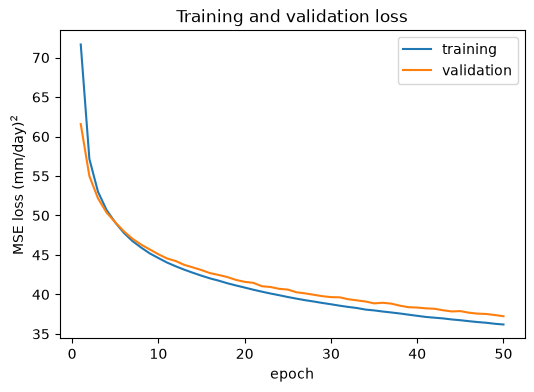

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
epochs = range(1, len(history["train"]) + 1)
ax.plot(epochs, history["train"], label="training")
ax.plot(epochs, history["val"], label="validation")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss (mm/day)$^2$")
ax.set_title("Training and validation loss")
ax.legend()
plt.show()

With a trained model in hand, the next two helpers turn it into something we can analyse.
`downscale` applies the model to any set of predictors and returns the predicted precipitation
as a labelled `xarray` map, it standardises the inputs with the **training** statistics
(exactly what we must do operationally) and clips the physically-impossible negative values (for precipitation) an
MSE model can occasionally produce. `align_time` simply makes a prediction and its reference
share the same time axis, so we can compare them day by day.


In [21]:
def downscale(model, predictors_ds, mean=None, std=None, batch=512):
    """Apply a trained model to a predictor Dataset -> precipitation DataArray (time, lat, lon).

    Predictors are standardized with the TRAINING statistics (mean/std), which is what we
    must do operationally: at projection time we only know the training-period statistics.
    """
    mean = PRED_MEAN if mean is None else mean
    std = PRED_STD if std is None else std
    x = predictors_to_array(predictors_ds, mean, std)

    model.eval()
    chunks = []
    with torch.no_grad():
        for i in range(0, len(x), batch):
            xb = torch.as_tensor(x[i:i + batch]).to(DEVICE)
            chunks.append(model(xb).cpu().numpy())
    pred = np.concatenate(chunks, axis=0)
    pred = pred.reshape(pred.shape[0], TARGET_LAT.size, TARGET_LON.size)

    da = xr.DataArray(pred,
                      dims=("time", "lat", "lon"),
                      coords={"time": predictors_ds["time"], "lat": TARGET_LAT, "lon": TARGET_LON},
                      name="pr")

    # Precipitation cannot be negative and an MSE-trained model can produce small negatives
    da = da.clip(min=0.0)
    da.attrs["units"] = "mm day-1"
    return da

def align_time(pred, obs):
    """Make sure prediction and reference share the same time axis (same period)."""
    assert pred.sizes["time"] == obs.sizes["time"], "prediction/reference length mismatch"
    return pred.assign_coords(time=obs["time"].values)

<a name="model-evaluation"></a>
# Model evaluation

To trust a projection, we first need to know the model works on data it has **never seen**. We
evaluate on the independent **1981-2000** test period, using the *perfect* predictors (the
best-case inputs), and compare the downscaled precipitation to the pseudo-reality.

A single error number is **not enough** for precipitation. Two models with the same RMSE can
behave completely differently on the things that matter (the wet/dry pattern, the day-to-day
variability and especially the **extremes** that drive floods and droughts). This is a
well-documented issue: standard validation metrics can miss structural problems that only
appear, for example, when a model is applied to a different region or a changing climate (see
González-Abad et al., 2023, https://doi.org/10.1029/2023MS003641). So we compute a small
battery of diagnostics, mirroring the CORDEX ML-Bench evaluation:

*   **RMSE**: the overall day-by-day error.
*   **Bias** (model - truth) of climate **indices**:
    *   **Mean** precipitation
    *   **P98**, the 98th percentile (the wet tail),
    *   **SDII** Simple Daily Intensity Index, the mean precipitation on wet days (≥ 1 mm), *how intense* rain is when it rains
    *   **RX1day** the mean annual maximum 1-day precipitation, a classic **extreme** index.

Where RMSE measures the average day-by-day *timing* error, the index **biases** instead ask
whether the model reproduces the right *statistical properties* of the precipitation
distribution (for instance its mean level, its tails and its extremes). In the summary table
each index bias is aggregated as the **mean absolute bias** over the domain, so that
overestimation in one region and underestimation in another do not cancel out. These
properties matter most for climate applications and are exactly what a single RMSE value
alone cannot reveal.


In [22]:
def idx_mean(da):
    return da.mean("time")

def idx_quantile(da, q):
    out = da.quantile(q, dim="time")
    return out.drop_vars("quantile", errors="ignore")

def idx_p98(da):
    return idx_quantile(da, 0.98)

def idx_sdii(da, wet_threshold=WET_DAY_THRESHOLD):
    """Mean precipitation on wet days (>= threshold)."""
    return da.where(da >= wet_threshold).mean("time")

def idx_rx1day(da):
    """Mean across years of the annual maximum 1-day precipitation."""
    return da.groupby("time.year").max("time").mean("year")

def rmse_map(obs, pred):
    return np.sqrt(((pred - obs) ** 2).mean("time"))

def index_bias(obs, pred, index_fn):
    """Spatial map of (model - truth) for a given index."""
    return index_fn(pred) - index_fn(obs)

# Indices we report, in display order.
INDEX_FUNCS = {"mean": idx_mean,
               "SDII": idx_sdii,
               "P98": idx_p98,
               "RX1day": idx_rx1day}

def summarize(obs, pred):
    """Return a one-row summary of spatially-averaged diagnostics (mm/day).

    Index biases are averaged in absolute value over the domain, so that
    overestimation in one area and underestimation in another do not cancel.
    """
    row = {"RMSE": float(rmse_map(obs, pred).mean())}
    for name, fn in INDEX_FUNCS.items():
        row[f"bias_{name}"] = float(np.abs(index_bias(obs, pred, fn)).mean())
    return row

We now run the trained model on the historical test predictors, turn the prediction into a
precipitation map aligned with the pseudo-reality and collect the spatially-averaged
diagnostics into a single summary table.


In [23]:
pred_pred = load_predictors(HIST_PERIOD, kind="perfect", gcm=GCM_TRAIN)
obs_hist = load_precip(HIST_PERIOD, gcm=GCM_TRAIN).load()

pr_pred_hist = align_time(downscale(model, pred_pred), obs_hist)

summary = summarize(obs_hist, pr_pred_hist)
summary_df = pd.DataFrame([summary], index=["DeepESD (perfect predictors)"]).round(3)

print("Spatially-averaged diagnostics on the 1981-2000 test period (mm/day):")
summary_df

Spatially-averaged diagnostics on the 1981-2000 test period (mm/day):


,RMSE,bias_mean,bias_SDII,bias_P98,bias_RX1day
DeepESD (perfect predictors),5.926,0.29,2.658,8.416,39.195


The table reports, for the 1981-2000 test period, the domain-averaged **RMSE** and the
**mean absolute bias** of each index, **all in mm/day** (RX1day is a daily-maximum amount, also
expressed in mm/day). A few patterns stand out: the **mean** bias is small (the model gets the
overall wet/dry level about right), but the upper tail is badly under-estimated, **SDII**,
**P98** and especially **RX1day** show much larger magnitudes than the mean, indicating the
model rains too little when it rains hardest (the bias maps below confirm this is typically an
under-estimation). This is the expected signature of MSE on raw precipitation.

Spatially-averaged numbers, however, hide *where* and *how* these errors arise. Before mapping
them, let us first look at the climatology and the extremes themselves, comparing the model
side by side with the pseudo-reality.


### Comparing the model and the truth: climatology and extremes

Below we map, for the historical test period, the **mean** precipitation (the climatology) and
three extreme statistics (**SDII**, **P98** and **RX1day**) for both the
**pseudo-reality (truth)** and the **DeepESD** prediction. Reading down each column you can
judge how faithfully the model reproduces each aspect of the precipitation
distribution before we quantify the differences as bias maps. Each column shares a common
colour scale so the truth and the model are directly comparable.

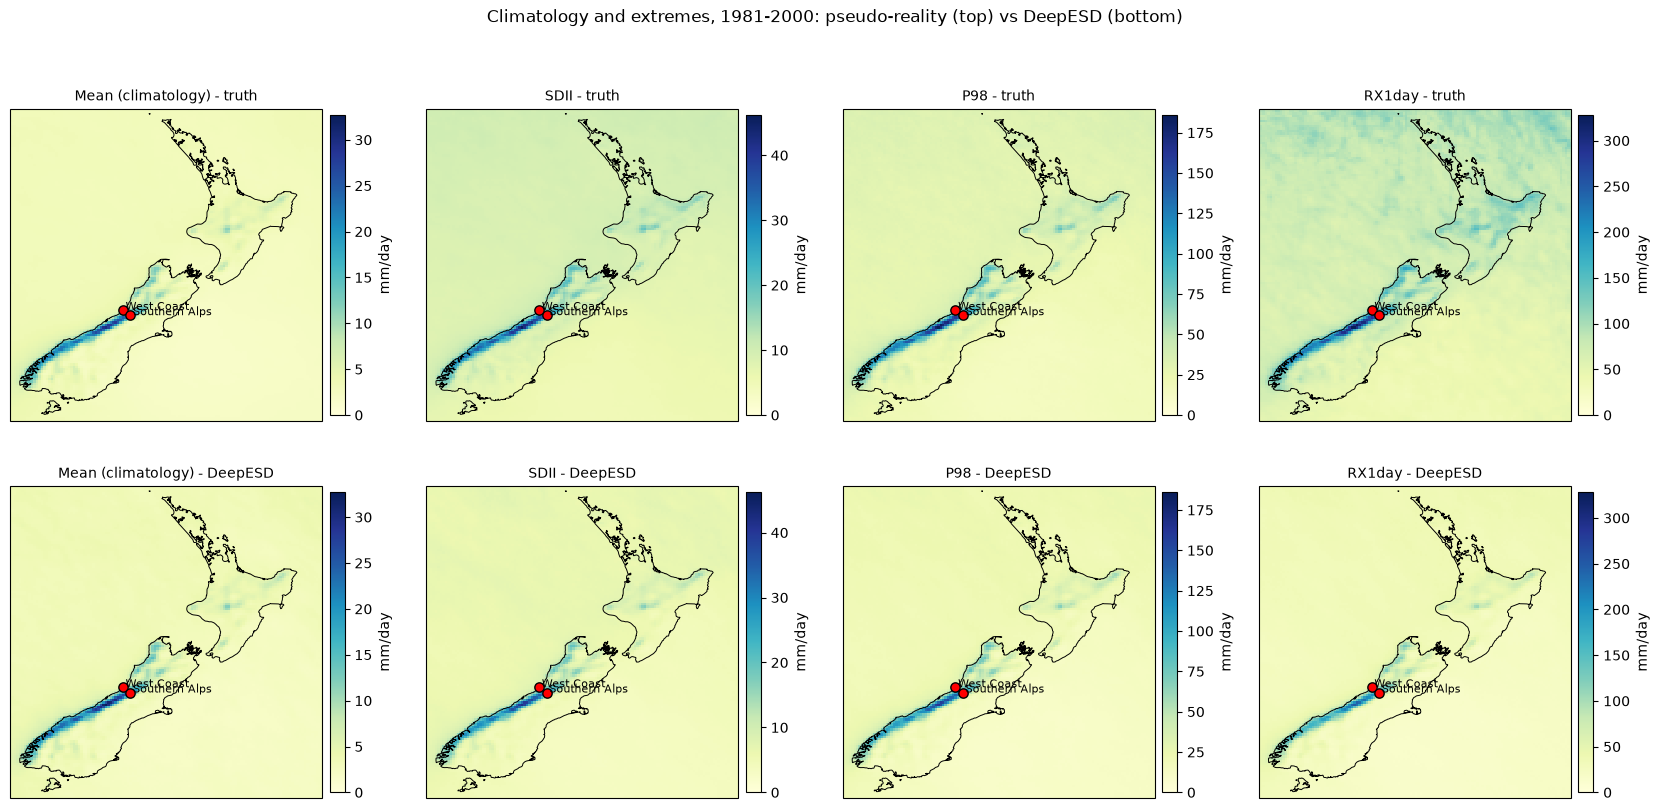

In [24]:
COMPARE_INDICES = {"Mean (climatology)": idx_mean,
                   "SDII": idx_sdii, "P98": idx_p98, "RX1day": idx_rx1day}

ncols = len(COMPARE_INDICES)
subplot_kw = {"projection": ccrs.PlateCarree()} if HAS_CARTOPY else {}
fig, axes = plt.subplots(2, ncols, figsize=(4.2 * ncols, 8.4), subplot_kw=subplot_kw)

for col, (name, fn) in enumerate(COMPARE_INDICES.items()):
    truth_field = fn(obs_hist)
    pred_field = fn(pr_pred_hist)
    vmax = float(max(truth_field.max(), pred_field.max()))  # shared scale per column
    plot_field(axes[0, col], truth_field, title=f"{name} - truth", cmap="YlGnBu",
               vmin=0, vmax=vmax, points=POINTS, cbar_label="mm/day", title_fontsize=10)
    plot_field(axes[1, col], pred_field, title=f"{name} - DeepESD", cmap="YlGnBu",
               vmin=0, vmax=vmax, points=POINTS, cbar_label="mm/day", title_fontsize=10)
fig.suptitle(f"Climatology and extremes, {HIST_PERIOD}: pseudo-reality (top) vs DeepESD (bottom)",
             y=1.01)
fig.tight_layout()
plt.show()

The eyeball comparison above is useful but qualitative. Now we quantify the errors as maps: the
**RMSE** and the **bias** (model - truth) of the mean, P98 and RX1day.


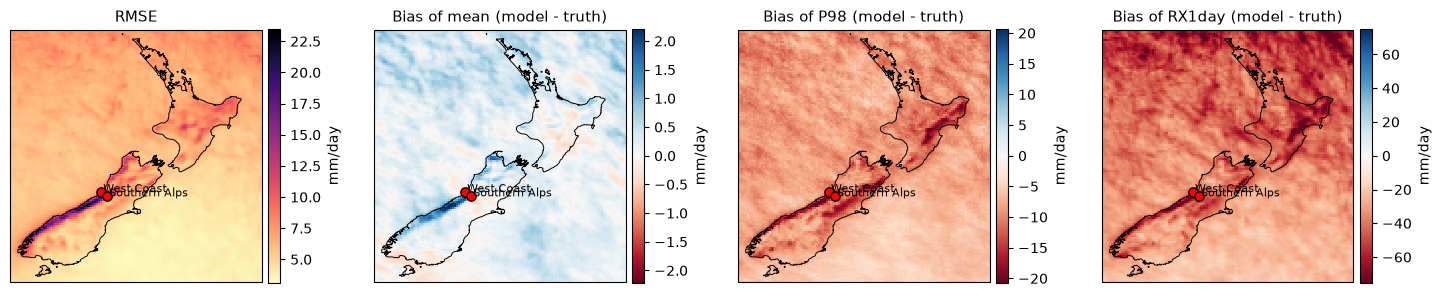

In [25]:
# Where are the errors? Maps of RMSE and index biases
rmse_field = rmse_map(obs_hist, pr_pred_hist)
bias_mean_field = index_bias(obs_hist, pr_pred_hist, idx_mean)
bias_p98_field = index_bias(obs_hist, pr_pred_hist, idx_p98)
bias_rx1_field = index_bias(obs_hist, pr_pred_hist, idx_rx1day)

fig, axes = make_map_axes(ncols=4, figsize=(18, 4.4))
plot_field(axes[0], rmse_field, title="RMSE", cmap="magma_r",
           points=POINTS, cbar_label="mm/day")
for ax, field, name in zip(
    axes[1:], [bias_mean_field, bias_p98_field, bias_rx1_field], ["mean", "P98", "RX1day"]
):
    v = float(np.nanmax(np.abs(field))) * 0.8
    plot_field(ax, field, title=f"Bias of {name} (model - truth)", cmap="RdBu",
               vmin=-v, vmax=v, points=POINTS, cbar_label="mm/day")
plt.show()

Two things usually stand out. The model captures the **mean** pattern quite well, it has
learned the West–East rain-shadow contrast that the coarse model could not see. For this metric,
DeepESD even slightly overestimates precipitation over the Southern Alps.
But look at **P98** and **RX1day**, the table shows much larger bias magnitudes than for the
mean, and the maps reveal that these errors are typically **negative**, meaning the model
**under-predicts the heaviest rainfall**. This is the expected downside of training with MSE
on raw precipitation.

> 🧭 **Question 2.** Compare the `bias_mean` value in the table with `bias_P98` and
> `bias_RX1day`. Which aspects of precipitation does the model reproduce well, and which
> does it struggle with? Why might under-estimating extremes be dangerous when the goal is
> to plan for floods?

> 🧭 **Question 3.** Two different models could have  *similar* RMSE but very different
> extreme biases. Why, then, is it important to report a *battery* of diagnostics rather
> than one number?

> ⚙️ **Try to improve it.** Increase `NUM_EPOCHS`, or try a
> bigger `FILTERS_LAST_CONV`, re-run training, and watch how the table and the extreme-bias
> maps change.

> **Answer.** RMSE is dominated by the many ordinary days, so it mostly rewards fitting
> the mean — two models can have near-identical RMSE while one badly misrepresents the
> tails. Since the impacts that matter (floods, droughts) live in those tails, only a
> battery of complementary diagnostics exposes the failure modes a single number hides.

> **Answer.** `bias_mean` is small while `bias_P98` and `bias_RX1day` are several times
> larger: the model reproduces the climatological mean well but struggles with extremes,
> because MSE training regresses toward the conditional mean and smooths the tails.
> Under-estimating extremes is dangerous for flood planning because defenses get sized
> for smaller events than actually occur — the plan fails exactly when it is needed.

<a name="gcm-projections"></a>
# GCM projections

Now we do the real job: generate **future** high-resolution precipitation. We feed the
model the large-scale predictors **from a GCM** for the end of the century (2080-2099) and
let it produce the local detail.

**One important difficulty first: a distribution shift.** Until now we used "perfect"
predictors (large-scale fields from the RCM). For real projections we must use the
**GCM's** own large-scale fields ("imperfect" predictors) and a GCM has its own biases,
so these inputs do not look exactly like what the model saw in training. Let's visualise
this shift for one predictor before trusting the projections.

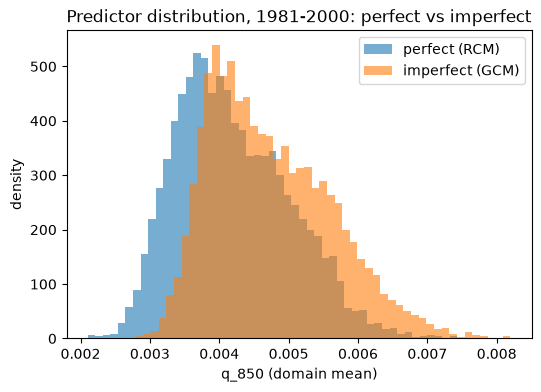

In [26]:
var_show = "q_850"  # 🔧 try other predictors, e.g. "t_500", "z_500"
pred_perfect_hist = load_predictors(HIST_PERIOD, kind="perfect", gcm=GCM_TRAIN)
pred_imperfect_hist = load_predictors(HIST_PERIOD, kind="imperfect", gcm=GCM_TRAIN)

# Domain-mean daily series of one variable, for the same historical period.
series_perfect = pred_perfect_hist[var_show].mean(["lat", "lon"]).values
series_imperfect = pred_imperfect_hist[var_show].mean(["lat", "lon"]).values

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(series_perfect, bins=50, alpha=0.6, density=True, label="perfect (RCM)")
ax.hist(series_imperfect, bins=50, alpha=0.6, density=True, label="imperfect (GCM)")
ax.set_xlabel(f"{var_show} (domain mean)")
ax.set_ylabel("density")
ax.set_title(f"Predictor distribution, {HIST_PERIOD}: perfect vs imperfect")
ax.legend()
plt.show()

> **A note on bias correction.** Because the GCM's large-scale fields differ statistically
> from the (perfect) predictors the model was trained on, a family of techniques called **bias
> correction** (or *bias adjustment*) is often used to make the GCM distribution match the
> training/observed one, either as a pre-processing step before the downscaling model or to
> post-process the GCM output directly. We do **not** cover bias correction in this tutorial,
> but it is widely used when generating this kind of projection and is well worth knowing
> about. See Maraun & Widmann (2018) for a thorough treatment.


### Downscaling the future

What stakeholders usually need is not the absolute amount of future rainfall but the
**change** relative to today: *will this place get wetter or drier, and by how much?* This
**climate change signal** is the difference between a future and a historical **climatology**, a multi-decadal (long-term) average. Over our two 20-year windows it is simply

$$\Delta = \overline{\text{precip}_\text{future}} - \overline{\text{precip}_\text{historical}}.$$

To obtain the **high-resolution** version of this signal we apply the trained model to a
GCM's **historical** and **future** large-scale predictors and difference the two downscaled
climatologies, separately for each driving GCM:

$$\Delta_\text{GCM} = \overline{\text{downscaled}(\text{future GCM predictors})} - \overline{\text{downscaled}(\text{historical GCM predictors})}.$$

Let's start with the training GCM, **ACCESS-CM2**, and compare what the *coarse* model
would say (the same flat change at both points) with what the *downscaled* model says.

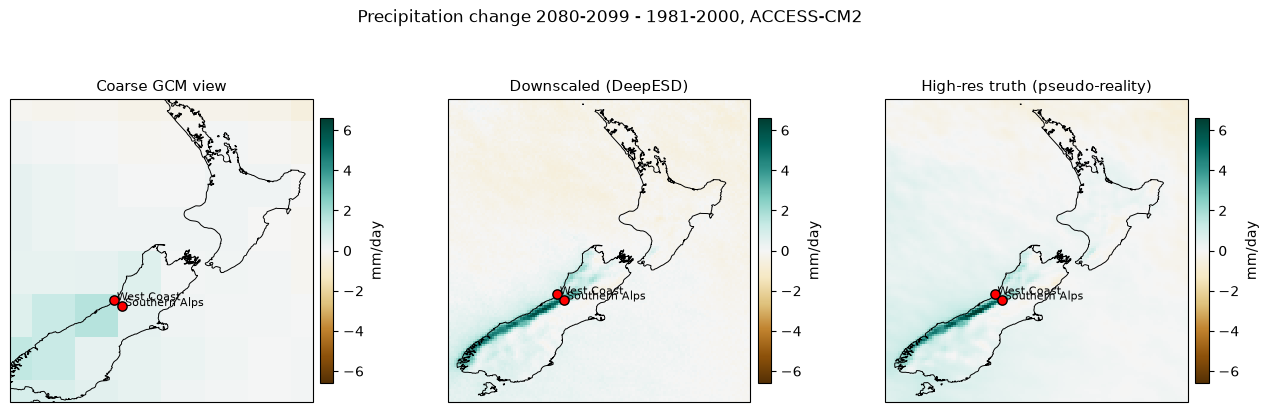

In [27]:
# ACCESS-CM2 (GCM_TRAIN)
pred_hist_access = load_predictors(HIST_PERIOD, kind="imperfect", gcm=GCM_TRAIN)
pred_future_access = load_predictors(FUTURE_PERIOD, kind="imperfect", gcm=GCM_TRAIN)
pr_ds_hist_access = downscale(model, pred_hist_access)
pr_ds_future_access = downscale(model, pred_future_access)
change_downscaled_access = pr_ds_future_access.mean("time") - pr_ds_hist_access.mean("time")

vlim = float(np.nanmax(np.abs(change_hi))) * 0.8
fig, axes = make_map_axes(ncols=3, figsize=(16, 4.6))
plot_field(axes[0], change_coarse, title="Coarse GCM view", cmap="BrBG",
           vmin=-vlim, vmax=vlim, points=POINTS, cbar_label="mm/day")
plot_field(axes[1], change_downscaled_access, title="Downscaled (DeepESD)", cmap="BrBG",
           vmin=-vlim, vmax=vlim, points=POINTS, cbar_label="mm/day")
plot_field(axes[2], change_hi, title="High-res truth (pseudo-reality)", cmap="BrBG",
           vmin=-vlim, vmax=vlim, points=POINTS, cbar_label="mm/day")
plt.suptitle(f"Precipitation change {FUTURE_PERIOD} - {HIST_PERIOD}, {GCM_TRAIN}", y=1.02)
plt.show()

Let’s also plot the bar chart showing the differences between the high- and coarse-resolution simulations for the points analyzed above.

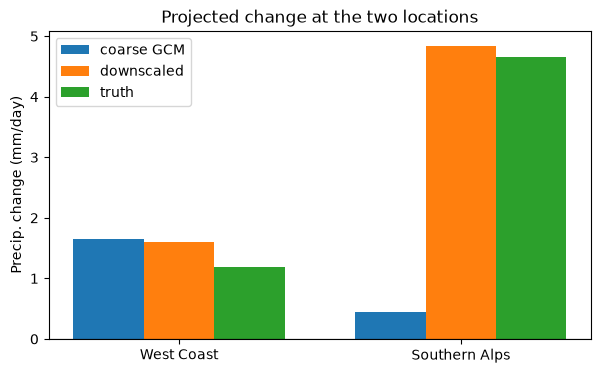

In [28]:
methods = {"coarse GCM": change_coarse, "downscaled": change_downscaled_access,
           "truth": change_hi}
x = np.arange(len(POINTS))
width = 0.25
fig, ax = plt.subplots(figsize=(7, 4))
for i, (label, field) in enumerate(methods.items()):
    vals = [float(sample_point(field, p)) for p in POINTS]
    ax.bar(x + (i - 1) * width, vals, width=width, label=label)
ax.axhline(0, color="k", linewidth=0.8)
ax.set_xticks(x, [p["name"].split(" (")[0] for p in POINTS])
ax.set_ylabel("Precip. change (mm/day)")
ax.set_title("Projected change at the two locations")
ax.legend()
plt.show()

The downscaled projection recovers a spatially varying climate change signal (different along the West Coast and in the Southern Alps), whereas the coarse-resolution view yields nearly identical values for both regions. When examining the projected change at the two locations analyzed above, we see that the downscaled projection produced by DeepESD is closer to the "pseudo-reality" than the coarse GCM projection itself. This suggests that the model is effective at "restoring" local-scale detail in the GCM projections.

### The same model, a different GCM

A key strength of statistical downscaling is that a single trained model can be applied to any GCM. Let us now apply the same DeepESD model to a second, independent GCM, **EC-Earth3**, and repeat the evaluation performed above, using the corresponding high-resolution data for this GCM as the reference.

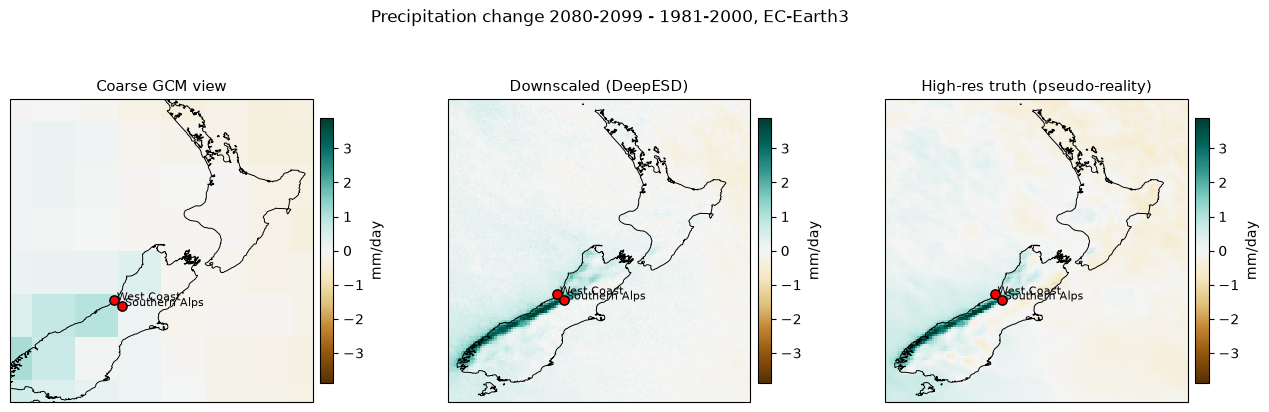

In [29]:
pred_hist_transfer = load_predictors(HIST_PERIOD, kind="imperfect", gcm=GCM_TRANSFER)
pred_future_transfer = load_predictors(FUTURE_PERIOD, kind="imperfect", gcm=GCM_TRANSFER)
pr_ds_hist_transfer = downscale(model, pred_hist_transfer)
pr_ds_future_transfer = downscale(model, pred_future_transfer)
change_downscaled_transfer = pr_ds_future_transfer.mean("time") - pr_ds_hist_transfer.mean("time")

pr_hist_clim_transfer = load_precip(HIST_PERIOD, gcm=GCM_TRANSFER).mean("time").compute()
pr_future_clim_transfer = load_precip(FUTURE_PERIOD, gcm=GCM_TRANSFER).mean("time").compute()
change_hi_transfer = pr_future_clim_transfer - pr_hist_clim_transfer
change_coarse_transfer = (upscale_to_coarse(pr_future_clim_transfer)
                          - upscale_to_coarse(pr_hist_clim_transfer))

vlim = float(np.nanmax(np.abs(change_hi_transfer))) * 0.8
fig, axes = make_map_axes(ncols=3, figsize=(16, 4.6))
plot_field(axes[0], change_coarse_transfer, title="Coarse GCM view", cmap="BrBG",
           vmin=-vlim, vmax=vlim, points=POINTS, cbar_label="mm/day")
plot_field(axes[1], change_downscaled_transfer, title="Downscaled (DeepESD)", cmap="BrBG",
           vmin=-vlim, vmax=vlim, points=POINTS, cbar_label="mm/day")
plot_field(axes[2], change_hi_transfer, title="High-res truth (pseudo-reality)", cmap="BrBG",
           vmin=-vlim, vmax=vlim, points=POINTS, cbar_label="mm/day")
plt.suptitle(f"Precipitation change {FUTURE_PERIOD} - {HIST_PERIOD}, {GCM_TRANSFER}", y=1.02)
plt.show()

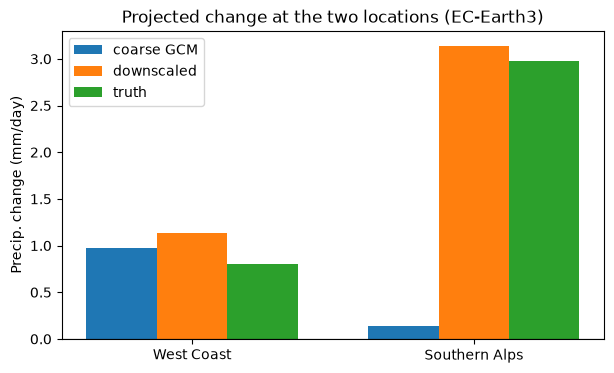

In [30]:
methods = {"coarse GCM": change_coarse_transfer, "downscaled": change_downscaled_transfer,
           "truth": change_hi_transfer}
x = np.arange(len(POINTS))
width = 0.25
fig, ax = plt.subplots(figsize=(7, 4))
for i, (label, field) in enumerate(methods.items()):
    vals = [float(sample_point(field, p)) for p in POINTS]
    ax.bar(x + (i - 1) * width, vals, width=width, label=label)
ax.axhline(0, color="k", linewidth=0.8)
ax.set_xticks(x, [p["name"].split(" (")[0] for p in POINTS])
ax.set_ylabel("Precip. change (mm/day)")
ax.set_title(f"Projected change at the two locations ({GCM_TRANSFER})")
ax.legend()
plt.show()

For the West Coast, the projected change is similar to that from ACCESS-CM2, but the Southern
Alps show a weaker signal (~3 mm/day vs ~5 mm/day). Despite this difference in the driving
GCM, DeepESD still resolves the regional contrast between the two locations — it correctly
projects a larger change in the Southern Alps than along the West Coast, consistent with the
pseudo-reality.

> **A note on GCM transferability.** The model was trained using predictors from ACCESS-CM2
> (the GCM that drove the RCM used for training), yet it produces physically coherent
> projections when driven by the independent EC-Earth3. This is encouraging, but the ability
> of statistical downscaling models to generalise to unseen driving GCMs is still an active
> area of research: transfer skill can degrade when the new GCM's large-scale circulation
> patterns differ substantially from those seen during training, so these results should be
> interpreted with appropriate caution.

<a name="conclusions"></a>
# Conclusions

**What we did.** We saw that a coarse climate model cannot distinguish
the very different climates of two nearby New Zealand locations. We then trained a small
convolutional network (DeepESD) to **downscale** daily precipitation from large-scale
predictors, evaluated it with a battery of diagnostics, and used it to generate **future
projections** driven by two different GCMs.

**Key takeaways.**

*   Downscaling adds the **local detail** that adaptation decisions need and that coarse GCMs
    cannot provide.
*   **RMSE is not enough.** A model can reproduce the mean pattern yet badly mis-represent
    **extremes**, exactly what matters for floods and droughts.
*   A single trained model can downscale **many GCMs** cheaply.
*   Moving from a tutorial model to **impact** still requires evaluation of extremes, careful
    treatment of GCM bias, and a clear handoff to decision processes (see *Pathway to
    deployment* under Climate Impact).

**Limitations to keep in mind.**

*   **Pseudo-reality, not observations.** Our "truth" is RCM output, a real application would
    train on observations, with their own gaps and biases.
*   **Stationarity assumption.** We assume the learned predictor-predictand relationship
    still holds in a much warmer future, a strong assumption when extrapolating.
*   **Distribution shift.** The model trains on near-perfect predictors but is applied to
    potentially "biased" GCM predictors.

## Improve DeepESD, your challenge

The training and evaluation code is modular, so you can experiment. Re-run training after
trying one or more of these, and watch the diagnostics table and the extreme-bias maps:

1.  **Train longer / change the learning rate**: raise `NUM_EPOCHS`, tune `LEARNING_RATE`.
2.  **More capacity**: increase `FILTERS_LAST_CONV` or add channels/layers to `DeepESD`.
3.  **Try to capture the extremes**: model precipitation in `log1p` space, or replace the MSE loss with
    one less dominated by the mean.
4.  **Add or remove information**: add or drop predictor variables / pressure levels in
    `PRED_VARS` and see how the skill changes.
5.  **Bring your own model**: define any `nn.Module` mapping `(N, 15, 16, 16) -> (N, 16384)`
    and pass it to `train_model(...)`, the whole evaluation pipeline just works. A ready-to-use
    **U-Net** example is provided at the end of the notebook to get you started.

> 🧭 **Final reflection.** Pick one change, predict *before* running whether it will help the
> mean, the extremes, or both and then test it. Did the result match your reasoning?

## Next steps

Try the other CORDEX ML-Bench regions, downscale temperature jointly with precipitation,
explore more expressive architectures (U-Nets, GANs, diffusion models) that better capture
extremes and small-scale texture, and consider bias-correcting the GCM predictors to reduce the
distribution shift.

> **Answer (worked example).** We did exactly this with the U-Net below. *Prediction:* its
> higher capacity and skip connections should preserve mean skill and reduce the extreme
> (P98/RX1day) biases. *Result:* after 30 epochs the U-Net does **not** beat DeepESD —
> RMSE 6.23 vs 5.93, mean bias 0.47 vs 0.29, P98 bias 9.64 vs 8.42 — with only RX1day
> slightly improved (37.2 vs 39.2). Two lessons: capacity alone does not fix extremes while
> the loss is still plain MSE, and the U-Net was still converging at epoch 30 (val loss
> 41.4 vs DeepESD 37.2), so a fair comparison needs longer training.

## An example for the challenge: a U-Net

To make the *"bring your own model"* challenge concrete, here is a small **U-Net**-style
architecture that is **drop-in compatible** with everything above. It takes the same
`(N, 15, 16, 16)` predictor tensor and returns the same flattened `(N, 16384)` precipitation
vector, so you can train and evaluate it with the exact same `train_model`, `downscale` and
diagnostic functions.

A U-Net is an encoder-decoder with **skip connections**, the encoder compresses the input into
increasingly abstract features, the decoder expands them back, and the skip connections
re-inject the fine spatial detail that pooling would otherwise discard. Here the network also
has to **upsample** from the coarse 16 × 16 predictor grid to the 128 × 128 target grid (a
factor of 8), which it does with a stack of bilinear-upsampling + convolution blocks.

To actually train it, replace the model-building step in the training section with
`model = build_unet()` (you may want to lower `NUM_EPOCHS` while experimenting), then re-run
the training and the whole evaluation and projection pipeline unchanged.

In [31]:
class UNetDownscaler(nn.Module):
    """A compact U-Net that downscales (N, n_predictors, 16, 16) -> (N, 128*128).
    """

    def __init__(self, n_predictors, out_hw=(128, 128), base=32):
        super().__init__()
        self.out_hw = out_hw

        def conv_block(c_in, c_out):return nn.Sequential(nn.Conv2d(c_in, c_out, 3, padding=1), nn.ReLU(inplace=True),
                                                         nn.Conv2d(c_out, c_out, 3, padding=1), nn.ReLU(inplace=True))

        # Encoder
        self.enc1 = conv_block(n_predictors, base)
        self.pool = nn.MaxPool2d(2)
        self.enc2 = conv_block(base, base * 2)

        # Decoder
        self.up = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.dec = conv_block(base * 2, base)

        # Upsample
        def up_block(c): return nn.Sequential(nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
                                              nn.Conv2d(c, c, 3, padding=1), nn.ReLU(inplace=True))
        self.to_target = nn.Sequential(up_block(base), up_block(base), up_block(base))
        self.head = nn.Conv2d(base, 1, kernel_size=1)

    def forward(self, x):

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))

        d = self.up(e2)
        d = self.dec(torch.cat([d, e1], dim=1))
        d = self.to_target(d)

        out = self.head(d)

        return torch.flatten(out, start_dim=1)

def build_unet():
    """Create a U-Net configured for the current data shapes."""
    return UNetDownscaler(n_predictors=len(PRED_VARS),
                          out_hw=(TARGET_LAT.size, TARGET_LON.size)).to(DEVICE)

_unet = build_unet()
_n_params = sum(p.numel() for p in _unet.parameters())
_dummy = torch.zeros(2, len(PRED_VARS),
                     predictors_train.sizes["lat"], predictors_train.sizes["lon"]).to(DEVICE)

print(f"U-Net trainable parameters: {_n_params:,}")
print(f"Output shape for a 2-sample batch: {tuple(_unet(_dummy).shape)}  "
      f"(expected (2, {N_GRIDPOINTS}))")

U-Net trainable parameters: 132,737


Output shape for a 2-sample batch: (2, 16384)  (expected (2, 16384))


### Training and evaluating the U-Net

Let's complete the challenge. Because the U-Net is drop-in compatible with the rest of the
notebook, we can train it with the exact same `train_model` function, evaluate it with the
same `downscale` + `summarize` pipeline, and compare it side by side with DeepESD.

In [32]:
# Train the U-Net with the same data, loss and optimizer as DeepESD.
UNET_EPOCHS = 30        # 🔧 fewer epochs than DeepESD: the U-Net is heavier per step
UNET_MODEL_PATH = MODELS_DIR / "unet_pr_nz.pt"

model_unet = build_unet()
print(f"Training U-Net for {UNET_EPOCHS} epochs on {DEVICE} ...")

# Track training emissions, exactly as we did for DeepESD
tracker = EmissionsTracker(project_name="unet_pr_nz_training",
                           output_dir=str(CODECARBON_DIR),
                           output_file="unet_training_emissions.csv",
                           log_level="error")
tracker.start()
history_unet = train_model(model_unet, train_loader, val_loader, num_epochs=UNET_EPOCHS)
emissions_unet = tracker.stop()

torch.save(model_unet.state_dict(), UNET_MODEL_PATH)
print(f"Saved trained U-Net to {UNET_MODEL_PATH}")
if emissions_unet is not None:
    print(f"CodeCarbon: training emissions ≈ {emissions_unet:.6f} kg CO₂eq")

model_unet.eval()

Training U-Net for 30 epochs on cpu ...


  epoch   1/30  train MSE 74.926  val MSE 68.553


  epoch   5/30  train MSE 61.407  val MSE 61.801


  epoch  10/30  train MSE 52.545  val MSE 52.475


  epoch  15/30  train MSE 47.729  val MSE 49.743


  epoch  20/30  train MSE 45.017  val MSE 46.141


  epoch  25/30  train MSE 42.450  val MSE 43.657


  epoch  30/30  train MSE 40.497  val MSE 41.383


Saved trained U-Net to models\unet_pr_nz.pt
CodeCarbon: training emissions ≈ 0.042494 kg CO₂eq


UNetDownscaler(
  (enc1): Sequential(
    (0): Conv2d(15, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (up): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
  (dec): Sequential(
    (0): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (to_target): Sequential(
    (0): Sequential(
      (0): Upsample(scale_factor=2.0, mode='bilinear')
      (1): Conv2d(32, 32, kernel_s

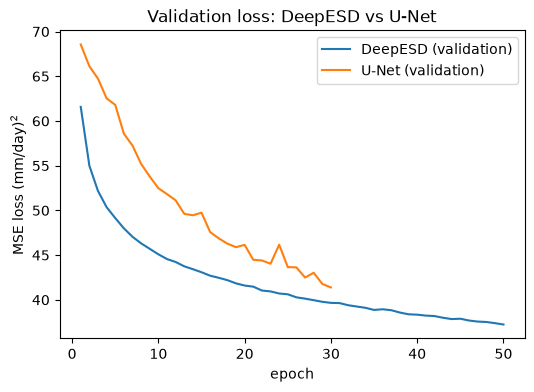

In [33]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(history["val"]) + 1), history["val"], label="DeepESD (validation)")
ax.plot(range(1, len(history_unet["val"]) + 1), history_unet["val"], label="U-Net (validation)")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss (mm/day)$^2$")
ax.set_title("Validation loss: DeepESD vs U-Net")
ax.legend()
plt.show()

In [34]:
# Evaluate the U-Net on the same historical test period (perfect predictors)
# and put both models in a single diagnostics table.
pr_unet_hist = align_time(downscale(model_unet, pred_pred), obs_hist)

comparison_df = pd.DataFrame([summarize(obs_hist, pr_pred_hist),
                              summarize(obs_hist, pr_unet_hist)],
                             index=["DeepESD", "U-Net"]).round(3)
print(f"Spatially-averaged diagnostics on the {HIST_PERIOD} test period (mm/day):")
comparison_df

Spatially-averaged diagnostics on the 1981-2000 test period (mm/day):


,RMSE,bias_mean,bias_SDII,bias_P98,bias_RX1day
DeepESD,5.926,0.290,2.658,8.416,39.195
U-Net,6.230,0.472,3.078,9.640,37.204


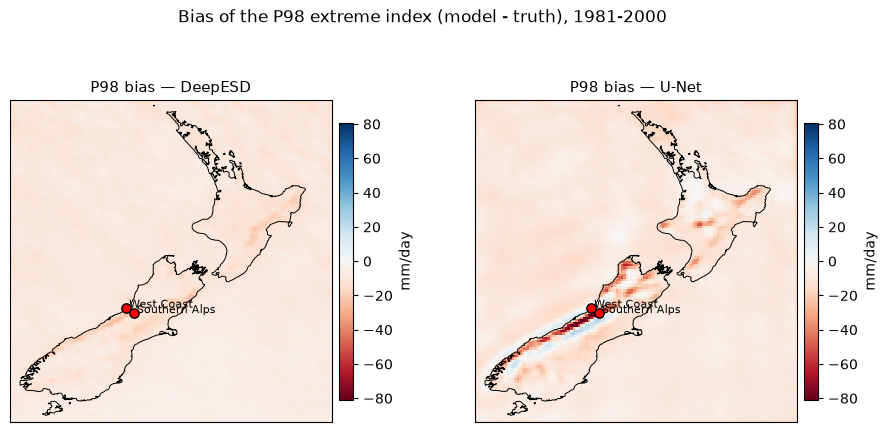

In [35]:
# Where do the two models differ on extremes? Bias maps of the P98 index.
bias_p98_deepesd = index_bias(obs_hist, pr_pred_hist, idx_p98)
bias_p98_unet = index_bias(obs_hist, pr_unet_hist, idx_p98)

# Shared symmetric color scale so the two maps are directly comparable
v = float(max(np.nanmax(np.abs(bias_p98_deepesd)), np.nanmax(np.abs(bias_p98_unet)))) * 0.8
fig, axes = make_map_axes(ncols=2, figsize=(11, 4.8))
plot_field(axes[0], bias_p98_deepesd, title="P98 bias — DeepESD", cmap="RdBu",
           vmin=-v, vmax=v, points=POINTS, cbar_label="mm/day")
plot_field(axes[1], bias_p98_unet, title="P98 bias — U-Net", cmap="RdBu",
           vmin=-v, vmax=v, points=POINTS, cbar_label="mm/day")
plt.suptitle(f"Bias of the P98 extreme index (model - truth), {HIST_PERIOD}", y=1.02)
plt.show()

## An additional note: other downscaling paradigms

Throughout this tutorial we have used the **perfect-prognosis** approach to statistical
downscaling (learning a predictor-predictand link in a historical period and applying it to a
GCM's large-scale fields). This is the **main approach used to generate regional climate
*projections* from GCMs** for future periods, and it is what most of the climate-downscaling
literature (and this tutorial) is about.

It is, however, not the only paradigm. A related but distinct family is **super-resolution**
downscaling, where a model learns to map a low-resolution field directly to its high-resolution
counterpart (often the *same* variable, e.g. coarse precipitation to fine precipitation).
Super-resolution is more naturally suited to the downscaling of **weather forecasts** than to
long-term climate projections. If you would like to explore this direction, we recommend the
review by Rampal et al. (2024), [*Enhancing regional climate downscaling through advances in machine learning*](https://journals.ametsoc.org/view/journals/aies/3/2/AIES-D-23-0066.1.xml).


<a name="references"></a>
# References

*   Rampal, N., González-Abad, J., Gibson, P., Engelbrecht, F., Steinkopf, J., & Hardy, C.
    (2026). *CORDEX-ML-Bench: A benchmarking dataset for data-driven regional climate
    downscaling.* Zenodo. https://doi.org/10.5281/zenodo.20985924
*   Tutorial NZ subset used in this notebook: https://doi.org/10.5281/zenodo.21425433
*   WCRP-CORDEX ML-Bench repository: https://github.com/WCRP-CORDEX/ml-benchmark
*   Baño-Medina, J., Manzanas, R., & Gutiérrez, J. M. (2022). *On the suitability of deep
    convolutional neural networks for continental-wide downscaling of climate change
    projections.* Geoscientific Model Development. https://link.springer.com/article/10.1007/s00382-021-05847-0
*   González-Abad, J., Baño-Medina, J., & Gutiérrez, J. M. (2023). *Using explainability to
    inform statistical downscaling based on deep learning beyond standard validation
    approaches.* Journal of Advances in Modeling Earth Systems, 15(11), e2023MS003641.
    https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2023MS003641
*   González-Abad, J., Iturbide, M., Hernanz, A., & Gutiérrez, J. M. (2026). *Pre-training for
    deep statistical climate downscaling: a case study within the Spanish National Adaptation
    Plan (PNACC).* Accepted on GMD. https://egusphere.copernicus.org/preprints/2025/egusphere-2025-3754/
*   Rampal, N., Hobeichi, S., Gibson, P. B., Baño-Medina, J., Abramowitz, G., Beucler, T.,
    González-Abad, J., Hodgson, W., Sun, Y., Vaughan, A., & Gutiérrez, J. M. (2024). *Enhancing
    regional climate downscaling through advances in machine learning.* Artificial Intelligence
    for the Earth Systems, 3(2). https://doi.org/10.1175/AIES-D-23-0066.1
*   Maraun, D., & Widmann, M. (2018). *Statistical Downscaling and Bias Correction for Climate
    Research.* Cambridge University Press.
